# Comparativa de Técnicas de Balanceo de Clases

### Objetivo
Comparar el rendimiento de **8 técnicas de balanceo** aplicadas al mismo pipeline predictivo
(Baseline → K-Fold → GridSearch → SHAP) para dos targets clínicos:
1. **Mortalidad postquirúrgica**
2. **Ingreso en UCI**

### Técnicas evaluadas

| Técnica | Tipo | Estrategia |
|---------|------|------------|
| **SMOTE** | Sintético (oversampling) | Interpolación uniforme entre vecinos |
| **BorderlineSMOTE** | Sintético (oversampling) | Solo genera en la frontera de decisión |
| **SVMSMOTE** | Sintético (oversampling) | Usa vectores de soporte de SVM |
| **ADASYN** | Sintético adaptativo (oversampling) | Más sintéticas en zonas difíciles |
| **RandomOverSampler** | Duplicación (oversampling) | Repite muestras reales sin generar nuevas |
| **RandomUnderSampler** | Undersampling directo | Elimina muestras aleatorias de la clase mayoritaria |
| **SMOTETomek** | Híbrido (over + under) | SMOTE + Tomek Links — limpieza suave de frontera |
| **SMOTEENN** | Híbrido (over + under) | SMOTE + ENN — limpieza agresiva de frontera |

### Modelos evaluados por técnica (7)
XGBoost, RandomForest, GradientBoosting, LogisticRegression, GaussianNB, ExtraTrees, LightGBM

### Métricas analizadas
- **PR-AUC** (métrica principal): Mejor para datos muy desbalanceados
- **AUC-ROC**: Discriminación general
- **Recall**: Sensibilidad — no perder casos positivos
- **F1**: Balance entre Precision y Recall

In [1]:
import os, pathlib
# Anclar CWD al root del proyecto (TFG/) independientemente de desde
# dónde se abra el notebook
_here = pathlib.Path().resolve()
if _here.name == 'notebooks':
    os.chdir(_here.parent)
print(f'Project root: {os.getcwd()}')

Project root: /Users/ikerarias/Desktop/TFG


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

---
## 1. Carga de resultados

In [3]:
# Cargar CSVs de cada técnica
archivos = {
    'SMOTE': 'results/tabla_comparativa_SMOTE.csv',
    'BorderlineSMOTE': 'results/tabla_comparativa_BorderlineSMOTE.csv',
    'SVMSMOTE': 'results/tabla_comparativa_SVMSMOTE.csv',
    'ADASYN': 'results/tabla_comparativa_ADASYN.csv',
    'RandomOverSampler': 'results/tabla_comparativa_RandomOverSampler.csv',
    'RandomUnderSampler': 'results/tabla_comparativa_RandomUnderSampler.csv',
    'SMOTETomek': 'results/tabla_comparativa_SMOTETomek.csv',
    'SMOTEENN': 'results/tabla_comparativa_SMOTEENN.csv'
}

dfs = []
for tecnica, archivo in archivos.items():
    try:
        df = pd.read_csv(archivo)
        df['Tecnica'] = tecnica
        dfs.append(df)
        print(f"✓ {tecnica}: {len(df)} filas")
    except FileNotFoundError:
        print(f"⚠ {tecnica}: archivo no encontrado ({archivo}) — se omite")

df_all = pd.concat(dfs, ignore_index=True)
print(f"\nDataset combinado: {df_all.shape[0]} filas × {df_all.shape[1]} columnas")
print(f"Técnicas: {df_all['Tecnica'].unique().tolist()}")
print(f"Fases: {df_all['Fase'].unique().tolist()}")
print(f"Modelos: {df_all['Modelo'].unique().tolist()}")
df_all.head()

✓ SMOTE: 42 filas
✓ BorderlineSMOTE: 42 filas
✓ SVMSMOTE: 42 filas
✓ ADASYN: 42 filas
✓ RandomOverSampler: 42 filas
✓ RandomUnderSampler: 42 filas
✓ SMOTETomek: 42 filas
✓ SMOTEENN: 42 filas

Dataset combinado: 336 filas × 14 columnas
Técnicas: ['SMOTE', 'BorderlineSMOTE', 'SVMSMOTE', 'ADASYN', 'RandomOverSampler', 'RandomUnderSampler', 'SMOTETomek', 'SMOTEENN']
Fases: ['Baseline', 'K-Fold (5)', 'GridSearch']
Modelos: ['XGBoost', 'RandomForest', 'GradientBoosting', 'LogisticRegression', 'GaussianNB', 'ExtraTrees', 'LightGBM']


,Target,Fase,Modelo,Accuracy,Precision,Recall,F1,AUC-ROC,PR-AUC,Sensitivity,Specificity,Info,Tiempo_seg,Tecnica
0,MORTALIDAD,Baseline,XGBoost,0.9633,0.1265,0.2162,0.1596,0.8690,0.0987,0.2162,0.9755,Params fijos,NaN,SMOTE
1,MORTALIDAD,Baseline,RandomForest,0.9594,0.1358,0.2823,0.1834,0.8922,0.1259,0.2823,0.9705,Params fijos,NaN,SMOTE
2,MORTALIDAD,Baseline,GradientBoosting,0.9689,0.1365,0.1742,0.1530,0.8718,0.0954,0.1742,0.9819,Params fijos,NaN,SMOTE
3,MORTALIDAD,Baseline,LogisticRegression,0.9231,0.1115,0.5405,0.1849,0.8879,0.1246,0.5405,0.9294,Params fijos,NaN,SMOTE
4,MORTALIDAD,Baseline,GaussianNB,0.8326,0.0618,0.6607,0.1130,0.8422,0.2011,0.6607,0.8354,Params fijos,NaN,SMOTE


---
## 2. Mejor modelo por técnica (GridSearch - PR-AUC)

Para cada técnica de balanceo, seleccionamos el **mejor modelo** según PR-AUC en la fase GridSearch (hiperparámetros optimizados), aplicando un **filtro de calidad** (AUC-ROC ≥ 0.6 y F1 ≥ 0.05) para evitar que modelos con probabilidades mal calibradas (e.g. GaussianNB) dominen la selección pese a un PR-AUC artificialmente elevado.

In [4]:
# Filtrar solo GridSearch (fase con hiperparámetros optimizados)
df_gs = df_all[df_all['Fase'] == 'GridSearch'].copy()

# Filtro de calidad: descartar modelos mal calibrados (e.g. GaussianNB con AUC-ROC < 0.6)
df_gs_calidad = df_gs[(df_gs['AUC-ROC'] >= 0.6) & (df_gs['F1'] >= 0.05)]

# Mejor modelo por técnica y target (sobre modelos que superan el filtro de calidad)
idx_best = df_gs_calidad.groupby(['Target', 'Tecnica'])['PR-AUC'].idxmax()
df_mejores = df_gs_calidad.loc[idx_best].sort_values(['Target', 'PR-AUC'], ascending=[True, False])

for target in ['MORTALIDAD', 'UCI']:
    print(f"\n{'='*100}")
    print(f"  MEJORES MODELOS POR TÉCNICA — {target}  (filtro: AUC-ROC ≥ 0.6, F1 ≥ 0.05)")
    print(f"{'='*100}\n")
    df_t = df_mejores[df_mejores['Target'] == target]
    cols = ['Tecnica', 'Modelo', 'PR-AUC', 'AUC-ROC', 'Recall', 'F1', 'Precision', 'Specificity']
    print(df_t[cols].to_string(index=False))
    
    best = df_t.iloc[0]
    print(f"\n  → GANADOR: {best['Tecnica']} + {best['Modelo']} (PR-AUC = {best['PR-AUC']:.4f})")



  MEJORES MODELOS POR TÉCNICA — MORTALIDAD  (filtro: AUC-ROC ≥ 0.6, F1 ≥ 0.05)

           Tecnica     Modelo  PR-AUC  AUC-ROC  Recall     F1  Precision  Specificity
          SMOTEENN GaussianNB  0.2346   0.8377  0.6697 0.1102     0.0600       0.8280
 RandomOverSampler GaussianNB  0.2111   0.8369  0.6126 0.1122     0.0617       0.8473
RandomUnderSampler GaussianNB  0.2106   0.8342  0.6336 0.1114     0.0611       0.8402
             SMOTE GaussianNB  0.2012   0.8423  0.6607 0.1131     0.0618       0.8356
        SMOTETomek GaussianNB  0.2011   0.8422  0.6607 0.1130     0.0618       0.8355
            ADASYN GaussianNB  0.1992   0.8425  0.6667 0.1138     0.0622       0.8352
   BorderlineSMOTE GaussianNB  0.1895   0.8433  0.6486 0.1173     0.0645       0.8456
          SVMSMOTE GaussianNB  0.1462   0.7899  0.5886 0.1218     0.0679       0.8676

  → GANADOR: SMOTEENN + GaussianNB (PR-AUC = 0.2346)

  MEJORES MODELOS POR TÉCNICA — UCI  (filtro: AUC-ROC ≥ 0.6, F1 ≥ 0.05)

           Tecnic

---
## 3. Visualización comparativa — GridSearch

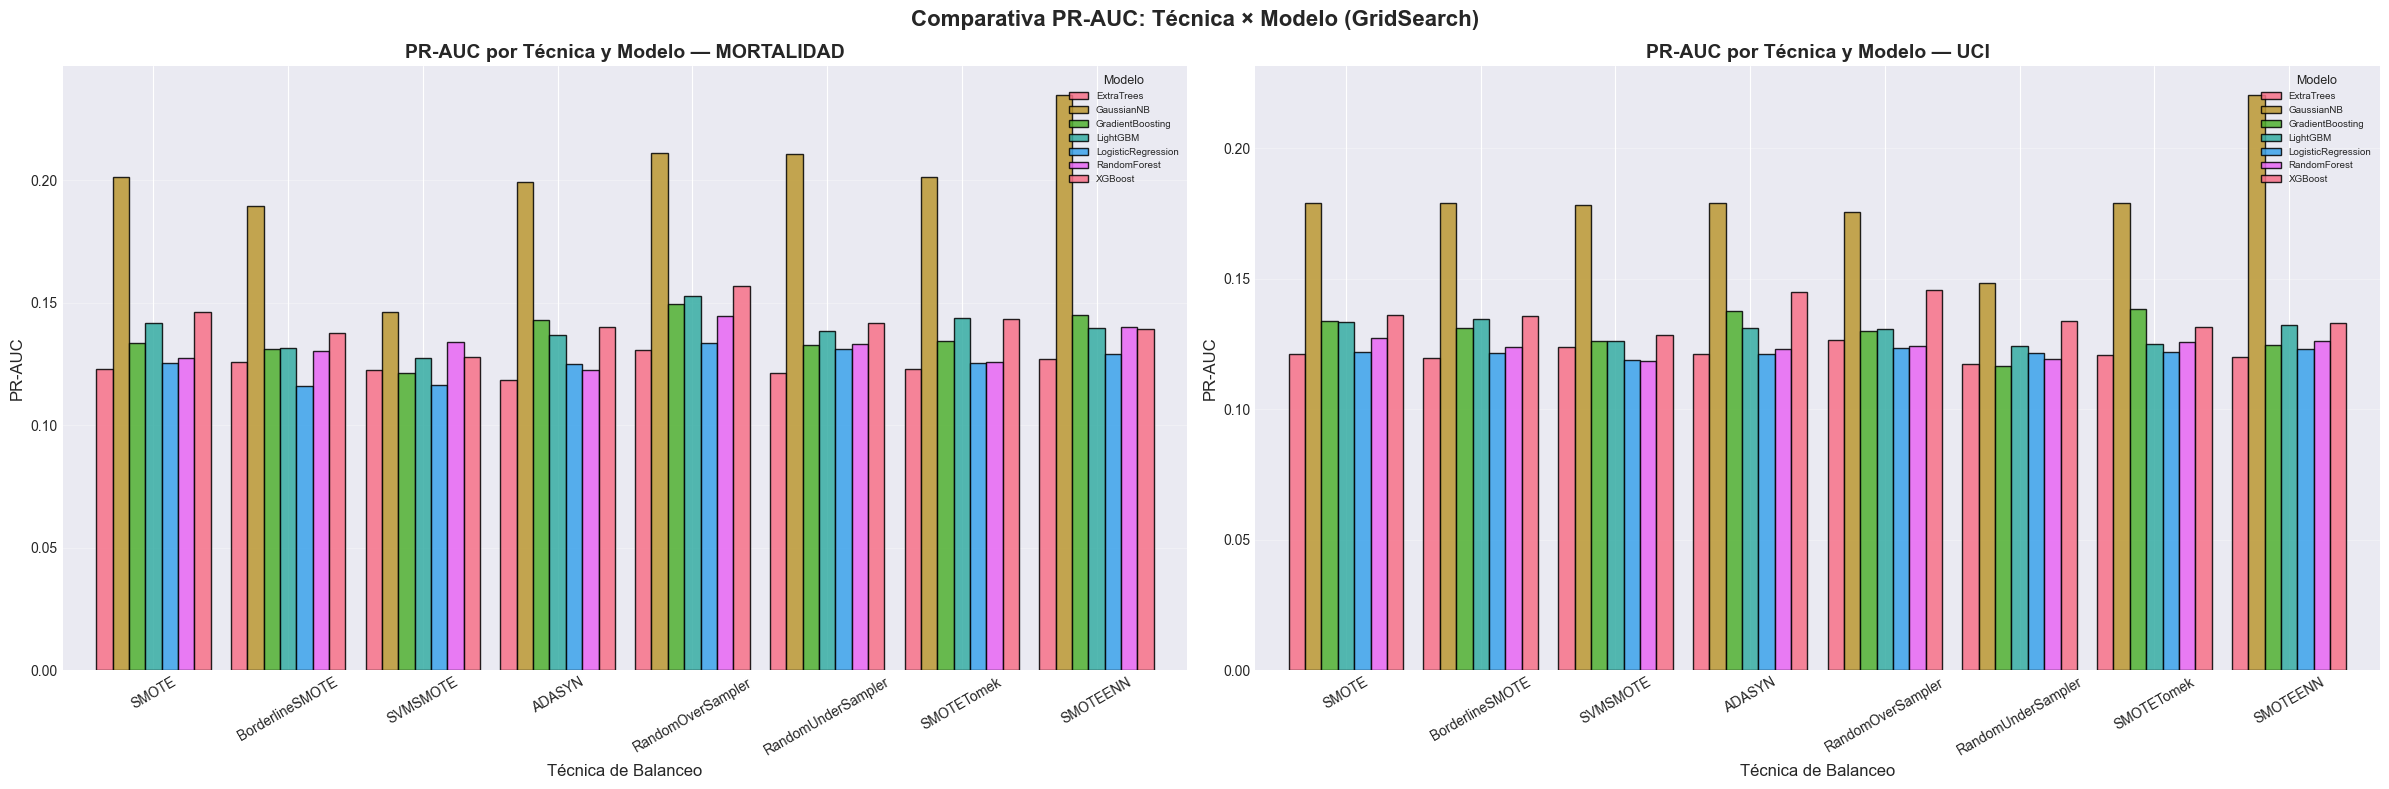

In [5]:
# ============================================================================
# GRÁFICO 1: PR-AUC por técnica y modelo (GridSearch)
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(24, 8))

for idx, target in enumerate(['MORTALIDAD', 'UCI']):
    ax = axes[idx]
    df_t = df_gs[df_gs['Target'] == target]
    
    pivot = df_t.pivot_table(index='Tecnica', columns='Modelo', values='PR-AUC', aggfunc='first')
    pivot = pivot.reindex(['SMOTE', 'BorderlineSMOTE', 'SVMSMOTE', 'ADASYN', 'RandomOverSampler', 'RandomUnderSampler', 'SMOTETomek', 'SMOTEENN'])
    
    pivot.plot(kind='bar', ax=ax, width=0.85, edgecolor='black', alpha=0.85)
    ax.set_title(f'PR-AUC por Técnica y Modelo — {target}', fontsize=14, fontweight='bold')
    ax.set_ylabel('PR-AUC', fontsize=12)
    ax.set_xlabel('Técnica de Balanceo', fontsize=12)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Modelo', fontsize=7, title_fontsize=9, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Comparativa PR-AUC: Técnica × Modelo (GridSearch)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

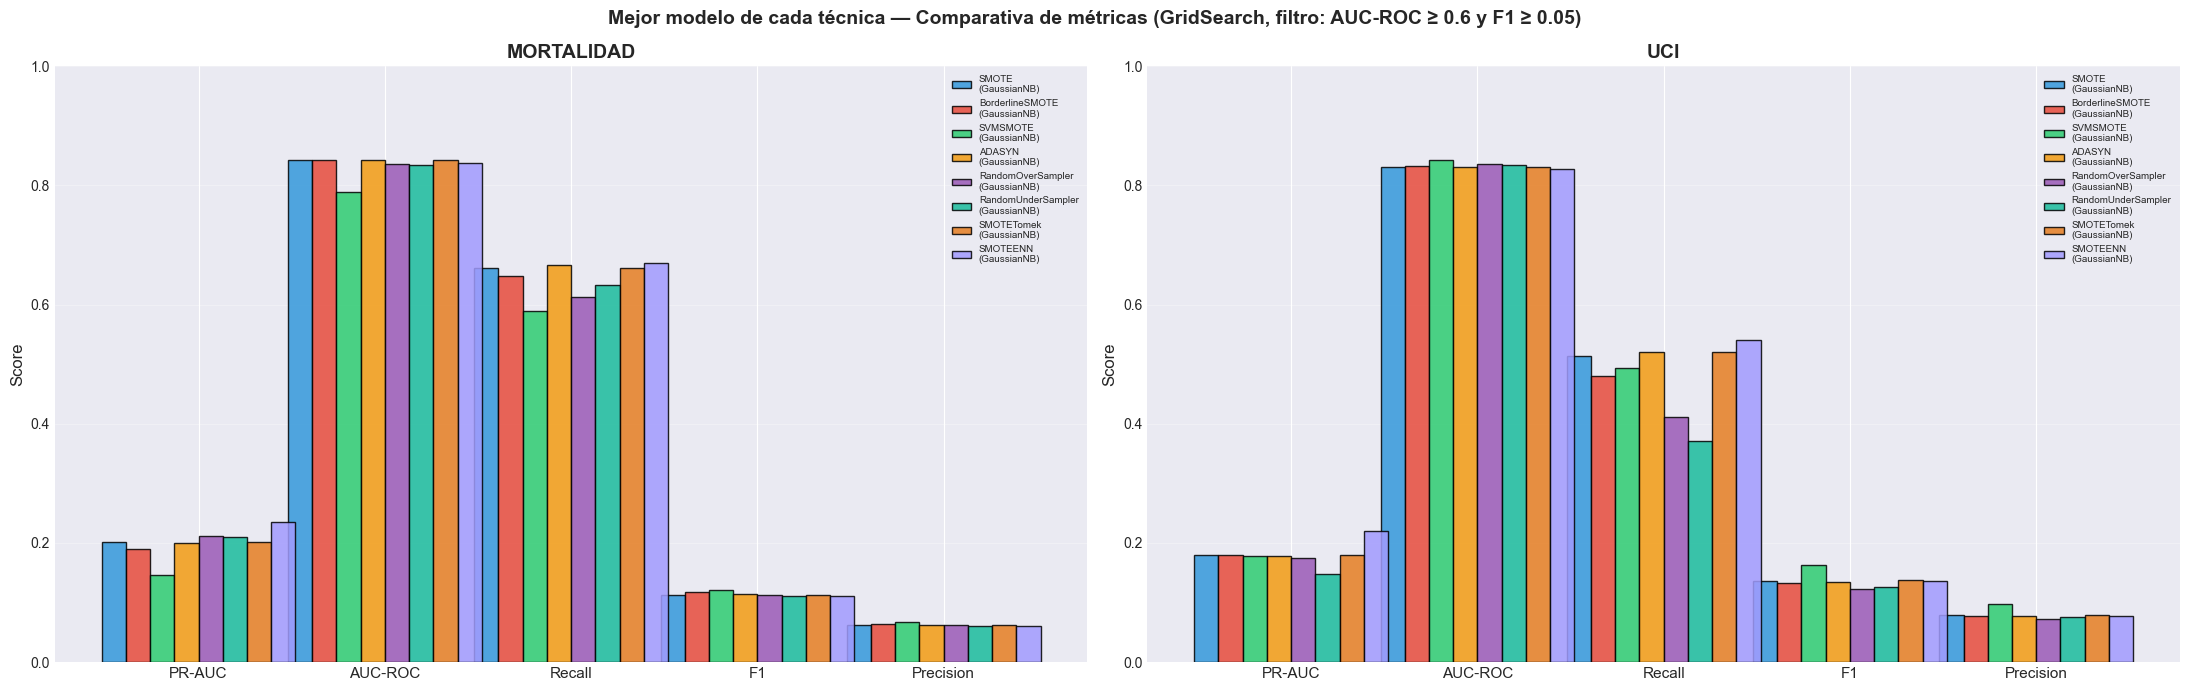

In [6]:
# ============================================================================
# GRÁFICO 2: Mejor modelo de cada técnica — comparativa directa
# ============================================================================

metricas_plot = ['PR-AUC', 'AUC-ROC', 'Recall', 'F1', 'Precision']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#a29bfe', '#fd79a8']
tecnicas_orden = ['SMOTE', 'BorderlineSMOTE', 'SVMSMOTE', 'ADASYN', 'RandomOverSampler', 'RandomUnderSampler', 'SMOTETomek', 'SMOTEENN']

fig, axes = plt.subplots(1, 2, figsize=(22, 7))

for idx, target in enumerate(['MORTALIDAD', 'UCI']):
    ax = axes[idx]
    df_t = df_mejores[df_mejores['Target'] == target]
    
    x = np.arange(len(metricas_plot))
    width = 0.13
    
    for i, tecnica in enumerate(tecnicas_orden):
        row = df_t[df_t['Tecnica'] == tecnica]
        if not row.empty:
            modelo = row.iloc[0]['Modelo']
            vals = [row.iloc[0][m] for m in metricas_plot]
            bars = ax.bar(x + i * width, vals, width, label=f'{tecnica}\n({modelo})',
                         color=colors[i], alpha=0.85, edgecolor='black')
    
    ax.set_xticks(x + width * 3.5)
    ax.set_xticklabels(metricas_plot, fontsize=11)
    ax.set_title(f'{target}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12)
    ax.set_ylim([0, 1])
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Mejor modelo de cada técnica — Comparativa de métricas (GridSearch, filtro: AUC-ROC ≥ 0.6 y F1 ≥ 0.05)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 3b. Distribución K-Fold PR-AUC por Técnica (fold-level)

Visualiza la **variabilidad entre los 5 folds** de K-Fold para el mejor modelo de cada técnica.
Requiere haber ejecutado los notebooks ntb_02 con las mejoras (genera `tabla_folds_*.csv`).

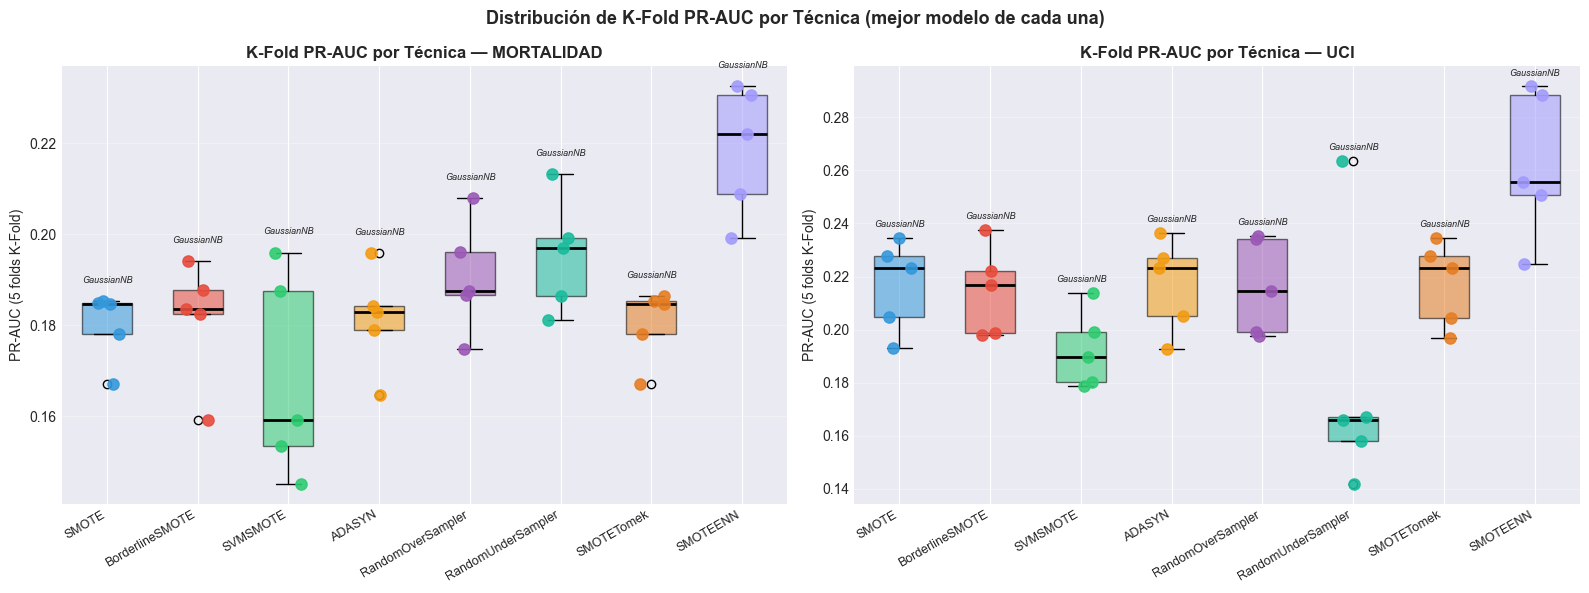

Datos de 8 técnicas cargados.


In [7]:
# ============================================================================
# K-FOLD PR-AUC DISTRIBUTION BY RESAMPLING STRATEGY
# Loaded from tabla_folds_*.csv
# ============================================================================
import glob

fold_dfs = []
for csv_path in sorted(glob.glob('results/tabla_folds_*.csv')):
    fold_dfs.append(pd.read_csv(csv_path))

if not fold_dfs:
    print('~ No tabla_folds_*.csv files found.')
    print('  Run the ntb_02 notebooks first.')
    df_folds_all = None
else:
    df_folds_all = pd.concat(fold_dfs, ignore_index=True)
    fold_cols = [c for c in df_folds_all.columns if c.startswith('fold_')]
    tecnicas_orden = ['SMOTE', 'BorderlineSMOTE', 'SVMSMOTE', 'ADASYN',
                      'RandomOverSampler', 'RandomUnderSampler', 'SMOTETomek', 'SMOTEENN']
    colors_8 = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12',
                '#9b59b6', '#1abc9c', '#e67e22', '#a29bfe']
    target_labels = {'MORTALIDAD': 'Mortality', 'UCI': 'Critical Care (ICU)'}

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    np.random.seed(SEED if 'SEED' in dir() else 42)

    for ax_idx, target in enumerate(['MORTALIDAD', 'UCI']):
        ax = axes[ax_idx]
        df_t = df_folds_all[df_folds_all['Target'] == target]

        # Best model per strategy (highest mean K-Fold PR-AUC)
        best_rows = []
        for tec in tecnicas_orden:
            sub = df_t[df_t['Tecnica'] == tec]
            if sub.empty:
                continue
            means = sub.groupby('Modelo')[fold_cols].mean().mean(axis=1)
            best_rows.append({'tecnica': tec, 'modelo': means.idxmax(),
                              'vals': sub[sub['Modelo'] == means.idxmax()][fold_cols].values.flatten()})

        # ── plot boxes ──────────────────────────────────────────────────────
        all_maxes = []
        for pos, info in enumerate(best_rows):
            col  = colors_8[pos % len(colors_8)]
            vals = info['vals']
            all_maxes.append(max(vals))
            ax.boxplot(vals, positions=[pos], widths=0.55, patch_artist=True,
                       boxprops=dict(facecolor=col, alpha=0.55),
                       medianprops=dict(color='black', lw=2),
                       whiskerprops=dict(color='#555555', lw=1.2),
                       capprops=dict(color='#555555', lw=1.5),
                       flierprops=dict(marker='o', markerfacecolor=col,
                                       markersize=4, alpha=0.5, linestyle='none'))
            jitter = np.random.uniform(-0.15, 0.15, len(vals))
            ax.scatter(np.full(len(vals), pos) + jitter, vals,
                       color=col, s=55, zorder=4, alpha=0.85,
                       edgecolors='white', linewidths=0.5)

        # extend y-axis BEFORE placing labels so they never clip
        y_top = max(all_maxes)
        ax.set_ylim(top=y_top + 0.030)

        for pos, info in enumerate(best_rows):
            ax.text(pos, max(info['vals']) + 0.007, info['modelo'],
                    ha='center', va='bottom', fontsize=6.5,
                    style='italic', color='#333333')

        ax.set_xticks(range(len(best_rows)))
        ax.set_xticklabels([r['tecnica'] for r in best_rows],
                           rotation=35, ha='right', fontsize=9)
        ax.set_ylabel('PR-AUC (5-fold cross-validation)', fontsize=11)
        ax.set_title(f'K-Fold PR-AUC by Resampling Strategy\n{target_labels[target]}',
                     fontweight='bold', fontsize=12)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.suptitle('K-Fold PR-AUC Distribution by Resampling Strategy'
                 ' (best classifier per strategy)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../imgs/prauc_kfold_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    # ── Individual figures (one per cohort, larger and more readable) ────────
    for target, fname_suffix in [('MORTALIDAD', 'mortality'), ('UCI', 'uci')]:
        df_t = df_folds_all[df_folds_all['Target'] == target]
        fig_s, ax_s = plt.subplots(figsize=(11, 6))
        np.random.seed(SEED if 'SEED' in dir() else 42)
        best_rows_s = []
        for tec in tecnicas_orden:
            sub = df_t[df_t['Tecnica'] == tec]
            if sub.empty:
                continue
            means = sub.groupby('Modelo')[fold_cols].mean().mean(axis=1)
            best_rows_s.append({'tecnica': tec, 'modelo': means.idxmax(),
                                 'vals': sub[sub['Modelo'] == means.idxmax()][fold_cols].values.flatten()})
        all_maxes_s = []
        for pos, info in enumerate(best_rows_s):
            col = colors_8[pos % len(colors_8)]
            vals = info['vals']
            all_maxes_s.append(max(vals))
            ax_s.boxplot(vals, positions=[pos], widths=0.55, patch_artist=True,
                         boxprops=dict(facecolor=col, alpha=0.55),
                         medianprops=dict(color='black', lw=2),
                         whiskerprops=dict(color='#555555', lw=1.2),
                         capprops=dict(color='#555555', lw=1.5),
                         flierprops=dict(marker='o', markerfacecolor=col,
                                         markersize=4, alpha=0.5, linestyle='none'))
            jitter = np.random.uniform(-0.15, 0.15, len(vals))
            ax_s.scatter(np.full(len(vals), pos) + jitter, vals,
                         color=col, s=55, zorder=4, alpha=0.85,
                         edgecolors='white', linewidths=0.5)
        y_top_s = max(all_maxes_s)
        ax_s.set_ylim(top=y_top_s + 0.030)
        for pos, info in enumerate(best_rows_s):
            ax_s.text(pos, max(info['vals']) + 0.007, info['modelo'],
                      ha='center', va='bottom', fontsize=8,
                      style='italic', color='#333333')
        ax_s.set_xticks(range(len(best_rows_s)))
        ax_s.set_xticklabels([r['tecnica'] for r in best_rows_s],
                             rotation=35, ha='right', fontsize=10)
        ax_s.set_ylabel('PR-AUC (5-fold cross-validation)', fontsize=12)
        ax_s.set_title(f'K-Fold PR-AUC by Resampling Strategy\n{target_labels[target]}',
                       fontweight='bold', fontsize=13)
        ax_s.grid(axis='y', alpha=0.3, linestyle='--')
        ax_s.spines['top'].set_visible(False)
        ax_s.spines['right'].set_visible(False)
        plt.tight_layout()
        plt.savefig(f'../imgs/prauc_kfold_{fname_suffix}.png', dpi=150, bbox_inches='tight')
        plt.show()

    print(f'Data from {df_folds_all["Tecnica"].nunique()} resampling strategies loaded.')


---
## 4. Heatmap — PR-AUC por técnica y modelo

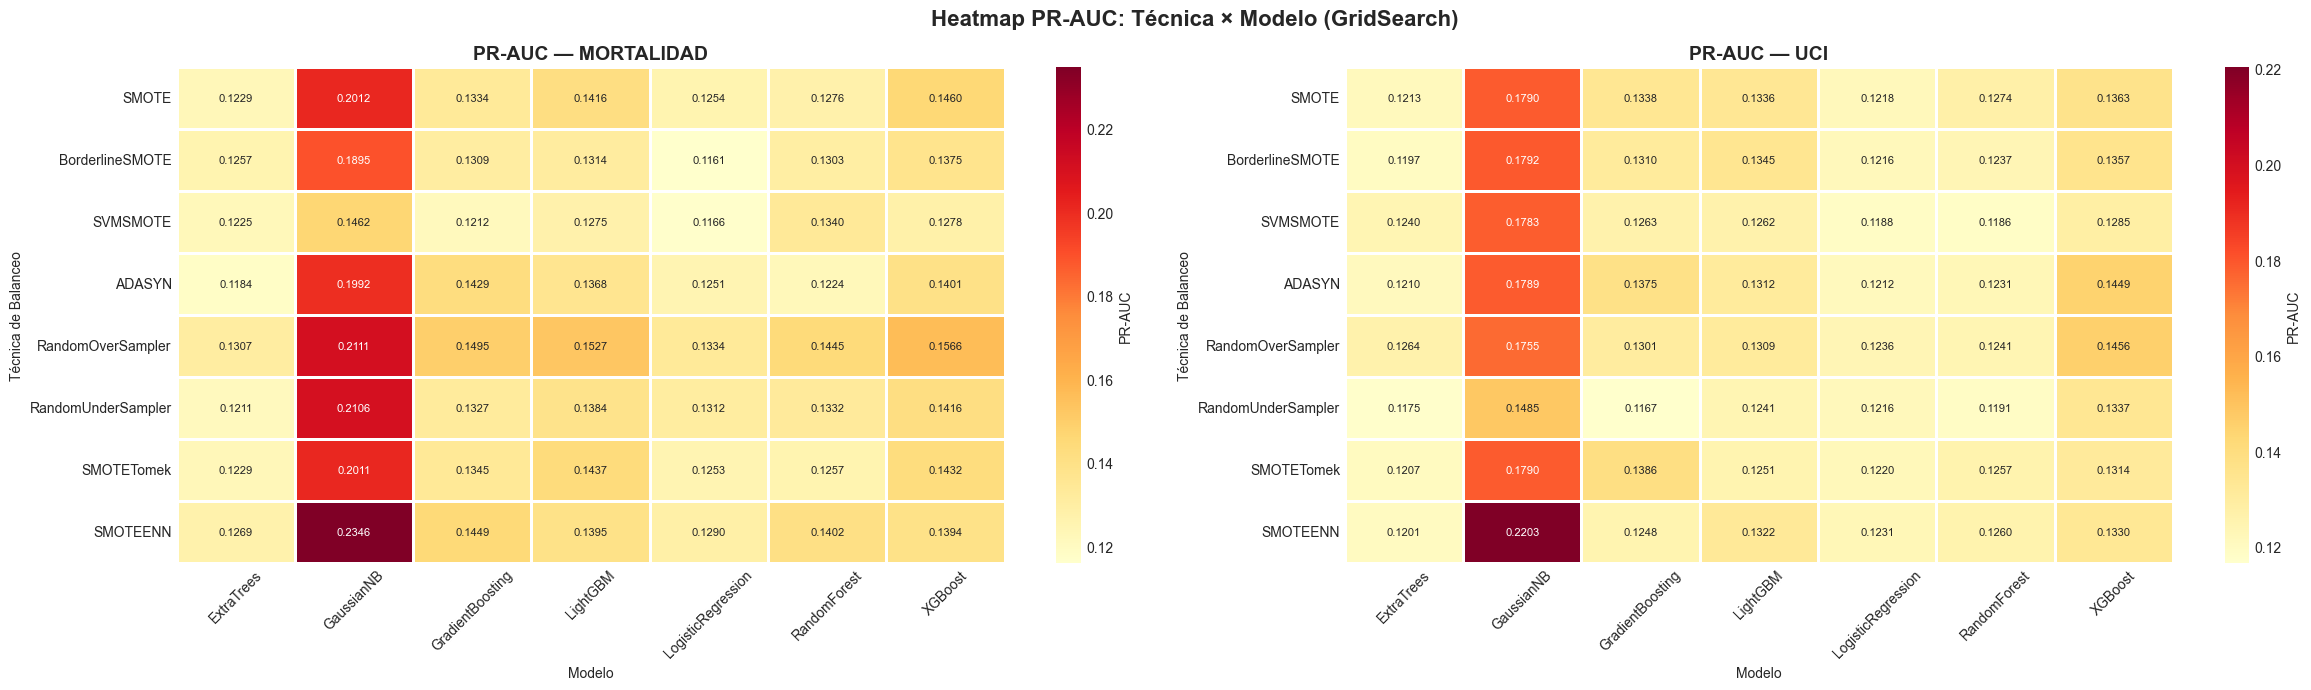

In [8]:
# ============================================================================
# HEATMAP: PR-AUC (técnica × modelo) para cada target
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(24, 7))
tecnicas_orden = ['SMOTE', 'BorderlineSMOTE', 'SVMSMOTE', 'ADASYN', 'RandomOverSampler', 'RandomUnderSampler', 'SMOTETomek', 'SMOTEENN']

for idx, target in enumerate(['MORTALIDAD', 'UCI']):
    ax = axes[idx]
    df_t = df_gs[df_gs['Target'] == target]
    
    pivot = df_t.pivot_table(index='Tecnica', columns='Modelo', values='PR-AUC', aggfunc='first')
    pivot = pivot.reindex(tecnicas_orden)
    
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax,
                linewidths=1, linecolor='white', cbar_kws={'label': 'PR-AUC'},
                annot_kws={'fontsize': 8})
    ax.set_title(f'PR-AUC — {target}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Técnica de Balanceo')
    ax.set_xlabel('Modelo')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Heatmap PR-AUC: Técnica × Modelo (GridSearch)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

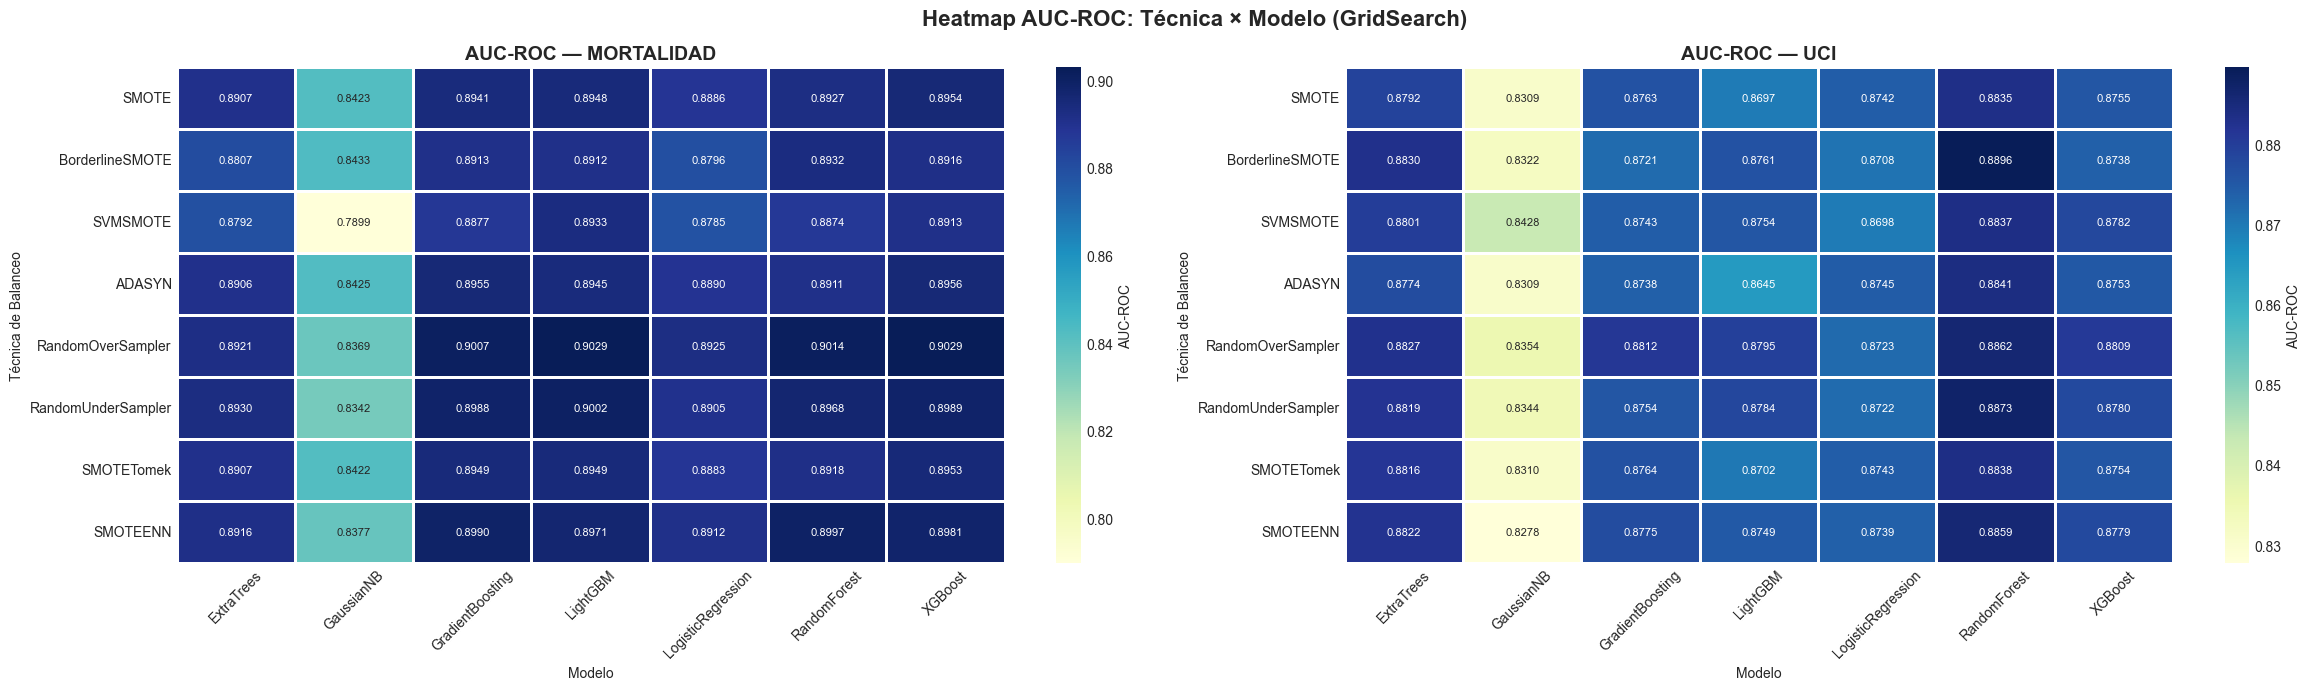

In [9]:
# ============================================================================
# HEATMAP: AUC-ROC (técnica × modelo) para cada target
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(24, 7))

for idx, target in enumerate(['MORTALIDAD', 'UCI']):
    ax = axes[idx]
    df_t = df_gs[df_gs['Target'] == target]
    
    pivot = df_t.pivot_table(index='Tecnica', columns='Modelo', values='AUC-ROC', aggfunc='first')
    pivot = pivot.reindex(tecnicas_orden)
    
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax,
                linewidths=1, linecolor='white', cbar_kws={'label': 'AUC-ROC'},
                annot_kws={'fontsize': 8})
    ax.set_title(f'AUC-ROC — {target}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Técnica de Balanceo')
    ax.set_xlabel('Modelo')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Heatmap AUC-ROC: Técnica × Modelo (GridSearch)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Análisis de robustez — K-Fold

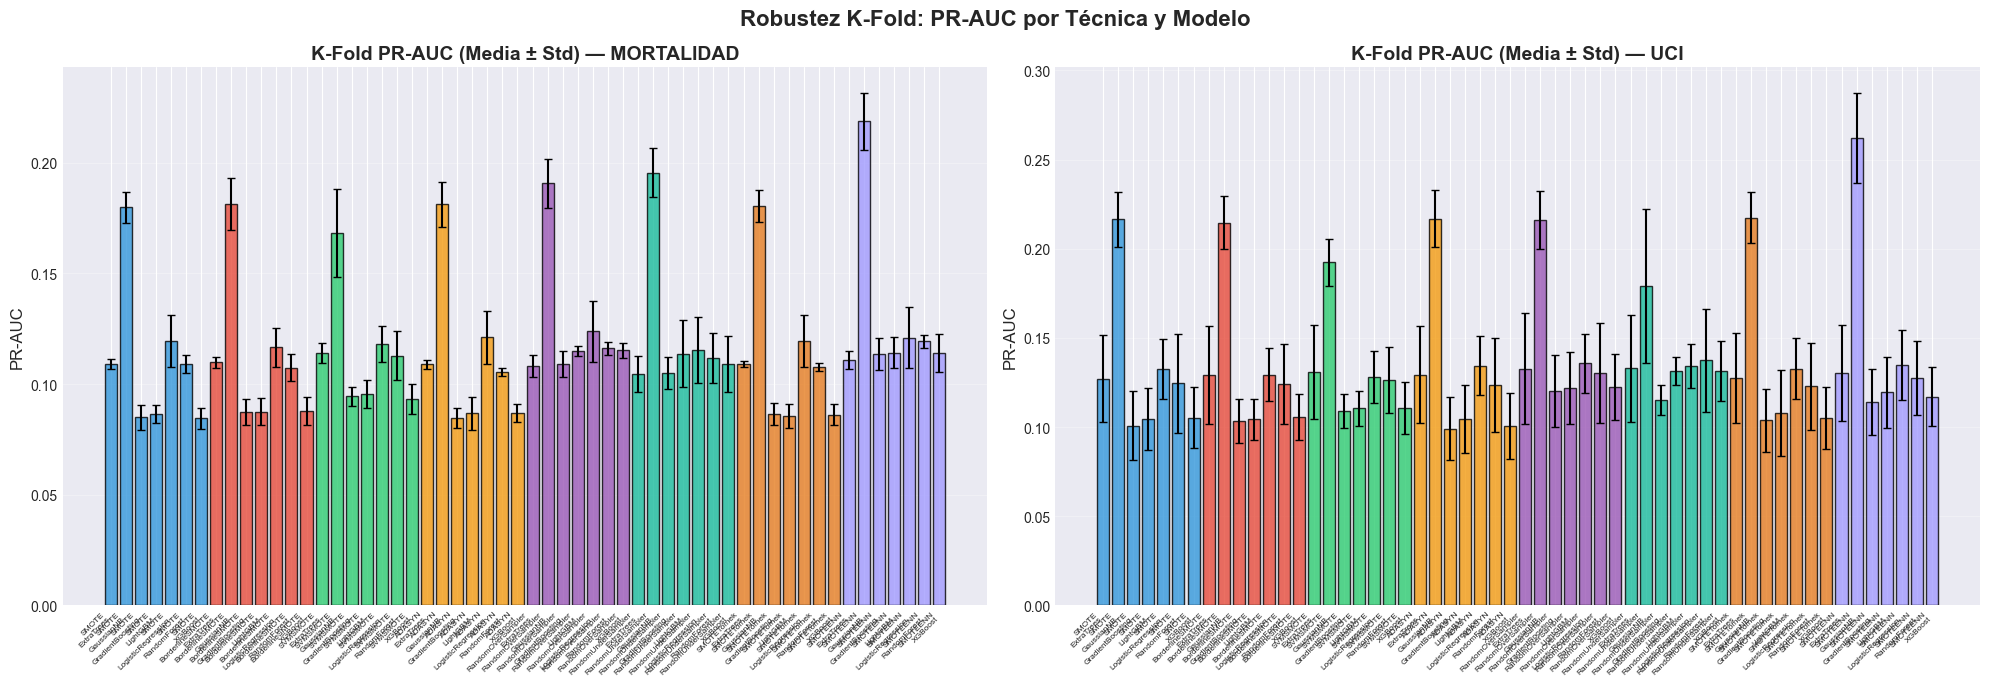

In [10]:
# ============================================================================
# K-FOLD: Extraer media y std de PR-AUC
# ============================================================================

df_kfold = df_all[df_all['Fase'] == 'K-Fold (5)'].copy()

# Extraer std del campo Info (formato: ±0.0123 (PR-AUC std))
df_kfold['PR-AUC_std'] = df_kfold['Info'].str.extract(r'±([\d.]+)').astype(float)

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#a29bfe']

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for idx, target in enumerate(['MORTALIDAD', 'UCI']):
    ax = axes[idx]
    df_t = df_kfold[df_kfold['Target'] == target].copy()
    
    # Ordenar por técnica (usar orden actualizado con RandomUnderSampler)
    cats = ['SMOTE', 'BorderlineSMOTE', 'SVMSMOTE', 'ADASYN', 'RandomOverSampler', 'RandomUnderSampler', 'SMOTETomek', 'SMOTEENN']
    df_t['Tecnica'] = pd.Categorical(df_t['Tecnica'], categories=cats, ordered=True)
    df_t = df_t.sort_values(['Tecnica', 'Modelo'])
    
    # Crear etiquetas combinadas
    df_t['Label'] = df_t['Tecnica'].astype(str) + '\n' + df_t['Modelo']
    
    # Colores por técnica
    color_map = dict(zip(cats, colors))
    bar_colors = [color_map[t] for t in df_t['Tecnica']]
    
    bars = ax.bar(range(len(df_t)), df_t['PR-AUC'].values,
                  yerr=df_t['PR-AUC_std'].values, capsize=3,
                  color=bar_colors, alpha=0.8, edgecolor='black')
    ax.set_xticks(range(len(df_t)))
    ax.set_xticklabels(df_t['Label'].values, fontsize=6, rotation=45, ha='right')
    ax.set_title(f'K-Fold PR-AUC (Media ± Std) — {target}', fontsize=14, fontweight='bold')
    ax.set_ylabel('PR-AUC', fontsize=12)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Robustez K-Fold: PR-AUC por Técnica y Modelo', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 5b. Consistencia GridSearch vs K-Fold

Verifica si el **modelo que gana en GridSearch** (evaluado en test set) coincide con el
**mejor modelo en K-Fold** (CV interno). Discrepancias pueden indicar sobreajuste al test set.

In [11]:
# ============================================================================
# CONSISTENCIA GS vs K-Fold: ¿coincide el ganador entre fases?
# ============================================================================

gs_df_c  = df_all[df_all['Fase'] == 'GridSearch'].copy()
kf_df_c  = df_all[df_all['Fase'] == 'K-Fold (5)'].copy()

# Aplicar filtro de calidad a GS
gs_cal_c = gs_df_c[(gs_df_c['AUC-ROC'] >= 0.6) & (gs_df_c['F1'] >= 0.05)]

tecnicas_c = ['SMOTE','BorderlineSMOTE','SVMSMOTE','ADASYN','RandomOverSampler','RandomUnderSampler','SMOTETomek','SMOTEENN']

print('=' * 100)
print('  CONSISTENCIA GridSearch vs K-Fold — Ganador por Técnica')
print('=' * 100)
mismatches = 0
for target in ['MORTALIDAD', 'UCI']:
    print(f"\n  TARGET: {target}")
    print(f"  {'Tecnica':<22} {'Ganador GS':<22} {'PR-AUC GS':>10} {'Ganador KF':<22} {'PR-AUC KF':>10} {'Match':>7}")
    print(f"  {'-' * 95}")
    for tec in tecnicas_c:
        gs_sub = gs_cal_c[(gs_cal_c['Target'] == target) & (gs_cal_c['Tecnica'] == tec)]
        kf_sub = kf_df_c[(kf_df_c['Target'] == target) & (kf_df_c['Tecnica'] == tec)]
        if gs_sub.empty or kf_sub.empty:
            print(f"  {tec:<22} {'—':<22} {'—':>10} {'—':<22} {'—':>10} {'—':>7}")
            continue
        best_gs = gs_sub.loc[gs_sub['PR-AUC'].idxmax()]
        best_kf = kf_sub.loc[kf_sub['PR-AUC'].idxmax()]
        match   = 'OK' if best_gs['Modelo'] == best_kf['Modelo'] else 'DIFF'
        if match == 'DIFF':
            mismatches += 1
        print(f"  {tec:<22} {best_gs['Modelo']:<22} {best_gs['PR-AUC']:>10.4f} "
              f"{best_kf['Modelo']:<22} {best_kf['PR-AUC']:>10.4f} {match:>7}")

print(f"\n  Total discrepancias: {mismatches} de {len(tecnicas_c)*2}")
if mismatches > 0:
    print('  DIFF indica que GS y K-Fold no coinciden en el mejor modelo.')
    print('  Posibles causas: varianza alta, sobreajuste al test set en GS.')

  CONSISTENCIA GridSearch vs K-Fold — Ganador por Técnica

  TARGET: MORTALIDAD
  Tecnica                Ganador GS              PR-AUC GS Ganador KF              PR-AUC KF   Match
  -----------------------------------------------------------------------------------------------
  SMOTE                  GaussianNB                 0.2012 GaussianNB                 0.1800      OK
  BorderlineSMOTE        GaussianNB                 0.1895 GaussianNB                 0.1814      OK
  SVMSMOTE               GaussianNB                 0.1462 GaussianNB                 0.1683      OK
  ADASYN                 GaussianNB                 0.1992 GaussianNB                 0.1813      OK
  RandomOverSampler      GaussianNB                 0.2111 GaussianNB                 0.1907      OK
  RandomUnderSampler     GaussianNB                 0.2106 GaussianNB                 0.1955      OK
  SMOTETomek             GaussianNB                 0.2011 GaussianNB                 0.1804      OK
  SMOTEENN    

---
## 8. Tests Estadísticos — ¿Son las diferencias entre técnicas significativas?

### Metodología
Usando los **5 valores de PR-AUC de K-Fold** (del mejor modelo de cada técnica) como
observaciones pareadas (mismo dataset, mismos folds), evaluamos:

1. **Test de Friedman**: equivalente no paramétrico a ANOVA de medidas repetidas
   - H₀: todas las técnicas tienen la misma distribución de PR-AUC
   - Rechazar H₀ si p < 0.05

2. **Wilcoxon pareado** (post-hoc): compara cada par + corrección de Bonferroni

*Requiere haber ejecutado la celda de distribución fold (sección 3b).*


  FRIEDMAN TEST — MORTALIDAD
  chi2 = 20.5333,   p-value = 0.004526
  H0 RECHAZADA: diferencias significativas ✓

  POST-HOC WILCOXON (Bonferroni alpha=0.05/28=0.0018)
  Tecnica A                 Tecnica B                    p-value    Sig   Media A   Media B
  -------------------------------------------------------------------------------------
  SMOTE                     BorderlineSMOTE               0.6250     ns    0.1800    0.1814
  SMOTE                     SVMSMOTE                      0.4375     ns    0.1800    0.1683
  SMOTE                     ADASYN                        1.0000     ns    0.1800    0.1813
  SMOTE                     RandomOverSampler             0.0625     ns    0.1800    0.1907
  SMOTE                     RandomUnderSampler            0.1250     ns    0.1800    0.1955
  SMOTE                     SMOTETomek                    1.0000     ns    0.1800    0.1804
  SMOTE                     SMOTEENN                      0.0625     ns    0.1800    0.2187
  Borde

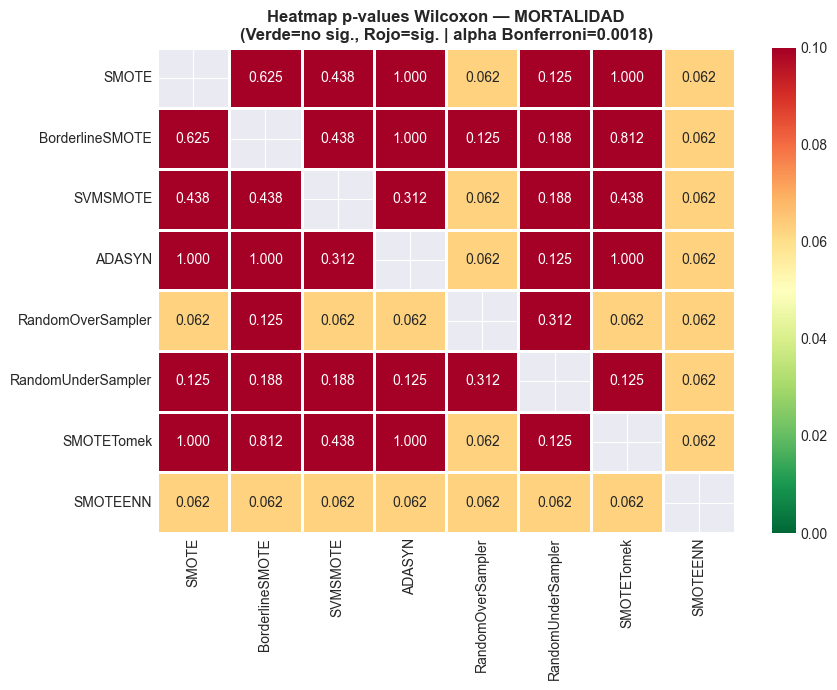


  FRIEDMAN TEST — UCI
  chi2 = 19.8974,   p-value = 0.005796
  H0 RECHAZADA: diferencias significativas ✓

  POST-HOC WILCOXON (Bonferroni alpha=0.05/28=0.0018)
  Tecnica A                 Tecnica B                    p-value    Sig   Media A   Media B
  -------------------------------------------------------------------------------------
  SMOTE                     BorderlineSMOTE               0.6250     ns    0.2166    0.2147
  SMOTE                     SVMSMOTE                      0.0625     ns    0.2166    0.1923
  SMOTE                     ADASYN                        1.0000     ns    0.2166    0.2169
  SMOTE                     RandomOverSampler             0.8125     ns    0.2166    0.2162
  SMOTE                     RandomUnderSampler            0.1875     ns    0.2166    0.1793
  SMOTE                     SMOTETomek                    0.3750     ns    0.2166    0.2174
  SMOTE                     SMOTEENN                      0.0625     ns    0.2166    0.2622
  BorderlineSM

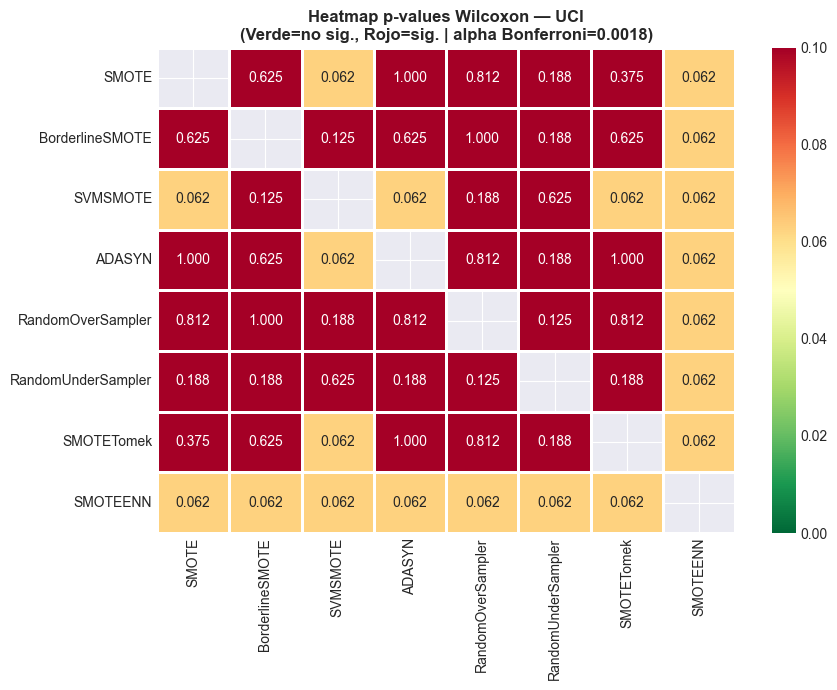


✓ Tests estadisticos completados


In [12]:
# ============================================================================
# TESTS ESTADÍSTICOS: FRIEDMAN + WILCOXON POST-HOC
# ============================================================================

from scipy.stats import friedmanchisquare, wilcoxon
from itertools import combinations

if 'df_folds_all' not in dir() or df_folds_all is None:
    print('Requiere ejecutar primero la sección 3b (carga de tabla_folds_*.csv).')
else:
    fold_cols_s  = [c for c in df_folds_all.columns if c.startswith('fold_')]
    tecnicas_s   = ['SMOTE','BorderlineSMOTE','SVMSMOTE','ADASYN','RandomOverSampler','RandomUnderSampler','SMOTETomek','SMOTEENN']

    for target in ['MORTALIDAD', 'UCI']:
        df_t = df_folds_all[df_folds_all['Target'] == target]

        # Mejor modelo por tecnica (mayor PR-AUC media K-Fold)
        best_map = {}
        for tec in tecnicas_s:
            sub = df_t[df_t['Tecnica'] == tec]
            if sub.empty:
                continue
            means = sub.groupby('Modelo')[fold_cols_s].mean().mean(axis=1)
            best_model_name = means.idxmax()
            vals = sub[sub['Modelo'] == best_model_name][fold_cols_s].values.flatten()
            best_map[tec] = vals

        if len(best_map) < 3:
            print(f'{target}: menos de 3 tecnicas con datos — test de Friedman no aplicable')
            continue

        # Test de Friedman
        stat, pval = friedmanchisquare(*list(best_map.values()))
        reject = pval < 0.05

        print(f"\n{'=' * 80}")
        print(f"  FRIEDMAN TEST — {target}")
        print(f"{'=' * 80}")
        print(f"  chi2 = {stat:.4f},   p-value = {pval:.6f}")
        print(f"  {'H0 RECHAZADA: diferencias significativas ✓' if reject else 'H0 no rechazada: sin evidencia de diferencias'}")

        # Wilcoxon post-hoc con correccion Bonferroni
        tecnicas_list = list(best_map.keys())
        n_pairs       = len(list(combinations(tecnicas_list, 2)))
        alpha_corr    = 0.05 / n_pairs

        print(f"\n  POST-HOC WILCOXON (Bonferroni alpha=0.05/{n_pairs}={alpha_corr:.4f})")
        print(f"  {'Tecnica A':<25} {'Tecnica B':<25} {'p-value':>10} {'Sig':>6} {'Media A':>9} {'Media B':>9}")
        print(f"  {'-' * 85}")

        pval_matrix   = np.ones((len(tecnicas_list), len(tecnicas_list)))
        for i, t1 in enumerate(tecnicas_list):
            for j, t2 in enumerate(tecnicas_list):
                if i >= j:
                    continue
                a, b = best_map[t1], best_map[t2]
                try:
                    _, pv = wilcoxon(a, b)
                except Exception:
                    pv = 1.0
                pval_matrix[i, j] = pval_matrix[j, i] = pv
                sig = '***' if pv < alpha_corr else ('*' if pv < 0.05 else 'ns')
                print(f"  {t1:<25} {t2:<25} {pv:>10.4f} {sig:>6} {np.mean(a):>9.4f} {np.mean(b):>9.4f}")

        # Heatmap de p-values
        import seaborn as _sns
        fig, ax = plt.subplots(figsize=(9, 7))
        annot = [[f'{pval_matrix[i,j]:.3f}' if i != j else '-'
                  for j in range(len(tecnicas_list))] for i in range(len(tecnicas_list))]
        _sns.heatmap(pval_matrix, annot=annot, fmt='s',
                     xticklabels=tecnicas_list, yticklabels=tecnicas_list,
                     cmap='RdYlGn_r', vmin=0, vmax=0.1,
                     linewidths=1, mask=np.eye(len(tecnicas_list), dtype=bool), ax=ax)
        ax.set_title(f'Heatmap p-values Wilcoxon — {target}\n'
                     f'(Verde=no sig., Rojo=sig. | alpha Bonferroni={alpha_corr:.4f})',
                     fontsize=12, fontweight='bold')
        plt.tight_layout(); plt.show()

    print('\n✓ Tests estadisticos completados')

---
## 6. Tabla resumen final

In [13]:
# ============================================================================
# TABLA RESUMEN: Ganadores absolutos y por target
# ============================================================================

print("=" * 120)
print("RESUMEN FINAL — MEJOR COMBINACIÓN TÉCNICA + MODELO POR TARGET")
print("(Filtro de calidad aplicado: AUC-ROC ≥ 0.6 y F1 ≥ 0.05)")
print("=" * 120)

resumen_data = []

for target in ['MORTALIDAD', 'UCI']:
    df_t = df_gs_calidad[df_gs_calidad['Target'] == target]
    
    # Mejor absoluto (GridSearch, sobre modelos de calidad)
    best_idx = df_t['PR-AUC'].idxmax()
    best = df_t.loc[best_idx]
    
    # K-Fold del mismo modelo/técnica
    kf_match = df_kfold[
        (df_kfold['Target'] == target) &
        (df_kfold['Modelo'] == best['Modelo']) &
        (df_kfold['Tecnica'] == best['Tecnica'])
    ]
    kf_prauc = kf_match.iloc[0]['PR-AUC'] if not kf_match.empty else np.nan
    kf_std = kf_match.iloc[0]['PR-AUC_std'] if not kf_match.empty else np.nan
    
    resumen_data.append({
        'Target': target,
        'Técnica': best['Tecnica'],
        'Modelo': best['Modelo'],
        'GS PR-AUC': round(best['PR-AUC'], 4),
        'GS AUC-ROC': round(best['AUC-ROC'], 4),
        'GS Recall': round(best['Recall'], 4),
        'GS F1': round(best['F1'], 4),
        'KF PR-AUC': round(kf_prauc, 4) if not np.isnan(kf_prauc) else '-',
        'KF Std': round(kf_std, 4) if not np.isnan(kf_std) else '-',
        'Params': best['Info']
    })
    
    print(f"\n{'─'*100}")
    print(f"  CAMPEÓN ABSOLUTO — {target}")
    print(f"{'─'*100}")
    print(f"  Técnica:         {best['Tecnica']}")
    print(f"  Modelo:          {best['Modelo']}")
    print(f"  GridSearch PR-AUC:  {best['PR-AUC']:.4f}")
    print(f"  GridSearch AUC-ROC: {best['AUC-ROC']:.4f}")
    print(f"  GridSearch Recall:  {best['Recall']:.4f}")
    print(f"  GridSearch F1:      {best['F1']:.4f}")
    print(f"  K-Fold PR-AUC:      {kf_prauc:.4f} ± {kf_std:.4f}" if not np.isnan(kf_prauc) else "  K-Fold: N/A")
    print(f"  Params:          {best['Info']}")

df_resumen = pd.DataFrame(resumen_data)
print(f"\n\n{'='*120}")
print(df_resumen.to_string(index=False))


RESUMEN FINAL — MEJOR COMBINACIÓN TÉCNICA + MODELO POR TARGET
(Filtro de calidad aplicado: AUC-ROC ≥ 0.6 y F1 ≥ 0.05)

────────────────────────────────────────────────────────────────────────────────────────────────────
  CAMPEÓN ABSOLUTO — MORTALIDAD
────────────────────────────────────────────────────────────────────────────────────────────────────
  Técnica:         SMOTEENN
  Modelo:          GaussianNB
  GridSearch PR-AUC:  0.2346
  GridSearch AUC-ROC: 0.8377
  GridSearch Recall:  0.6697
  GridSearch F1:      0.1102
  K-Fold PR-AUC:      0.2187 ± 0.0128
  Params:          {'var_smoothing': 1e-05}

────────────────────────────────────────────────────────────────────────────────────────────────────
  CAMPEÓN ABSOLUTO — UCI
────────────────────────────────────────────────────────────────────────────────────────────────────
  Técnica:         SMOTEENN
  Modelo:          GaussianNB
  GridSearch PR-AUC:  0.2203
  GridSearch AUC-ROC: 0.8278
  GridSearch Recall:  0.5405
  GridSearch F1:  

In [14]:
# ============================================================================
# RANKING COMPLETO: Todas las técnicas ordenadas por PR-AUC (GridSearch)
# Sin filtro — muestra todos los modelos para referencia y análisis completo
# ============================================================================

for target in ['MORTALIDAD', 'UCI']:
    print(f"\n{'='*120}")
    print(f"  RANKING COMPLETO — {target} (GridSearch, sin filtro, ordenado por PR-AUC)")
    print(f"{'='*120}\n")
    
    df_t = df_gs[df_gs['Target'] == target].sort_values('PR-AUC', ascending=False)
    df_t = df_t.reset_index(drop=True)
    df_t.index = df_t.index + 1  # ranking from 1
    df_t.index.name = 'Rank'
    
    cols = ['Tecnica', 'Modelo', 'PR-AUC', 'AUC-ROC', 'Recall', 'F1', 'Precision', 'Specificity']
    print(df_t[cols].to_string())
    
    # Señalar modelos que no pasan el filtro de calidad
    descartados = df_gs[(df_gs['Target'] == target) & 
                        ((df_gs['AUC-ROC'] < 0.6) | (df_gs['F1'] < 0.05))]
    if not descartados.empty:
        print(f"\n  ⚠ Modelos excluidos del ranking de selección (AUC-ROC < 0.6 o F1 < 0.05):")
        for _, row in descartados.sort_values('PR-AUC', ascending=False).iterrows():
            print(f"    - {row['Tecnica']} + {row['Modelo']}: PR-AUC={row['PR-AUC']:.4f}, AUC-ROC={row['AUC-ROC']:.4f}, F1={row['F1']:.4f}")



  RANKING COMPLETO — MORTALIDAD (GridSearch, sin filtro, ordenado por PR-AUC)

                 Tecnica              Modelo  PR-AUC  AUC-ROC  Recall      F1  Precision  Specificity
Rank                                                                                                 
1               SMOTEENN          GaussianNB  0.2346   0.8377  0.6697  0.1102     0.0600       0.8280
2      RandomOverSampler          GaussianNB  0.2111   0.8369  0.6126  0.1122     0.0617       0.8473
3     RandomUnderSampler          GaussianNB  0.2106   0.8342  0.6336  0.1114     0.0611       0.8402
4                  SMOTE          GaussianNB  0.2012   0.8423  0.6607  0.1131     0.0618       0.8356
5             SMOTETomek          GaussianNB  0.2011   0.8422  0.6607  0.1130     0.0618       0.8355
6                 ADASYN          GaussianNB  0.1992   0.8425  0.6667  0.1138     0.0622       0.8352
7        BorderlineSMOTE          GaussianNB  0.1895   0.8433  0.6486  0.1173     0.0645       0.8456
8 

---
## 7. Guardar resultados consolidados

In [15]:
# Guardar tabla consolidada con todas las técnicas
df_all.to_csv('results/comparativa_todas_tecnicas.csv', index=False)
print(f"✓ Guardado: comparativa_todas_tecnicas.csv ({len(df_all)} filas)")

# Guardar resumen de ganadores
df_resumen.to_csv('results/resumen_ganadores_oversampling.csv', index=False)
print(f"✓ Guardado: resumen_ganadores_oversampling.csv")

✓ Guardado: comparativa_todas_tecnicas.csv (336 filas)
✓ Guardado: resumen_ganadores_oversampling.csv


---
## 9. Análisis Profundo del Modelo Ganador

Una vez identificado el campeón absoluto en la comparativa, profundizamos en su
comportamiento clínico y estadístico con:

- **9.1** — Identificación del ganador y carga del checkpoint
- **9.2** — Curvas PR y ROC con IC 95% (bootstrap, n=1 000)
- **9.3** — Recalibración probabilística (Isotonic Regression)
- **9.4** — Análisis del umbral de decisión y matrices de confusión
- **9.5** — Importancia de variables (SHAP)
- **9.6** — Tabla clínica final para la defensa del TFG


### 9.1 — Identificar ganador y cargar checkpoint

In [16]:
# ============================================================================
# GANADOR ABSOLUTO — identificado de df_gs_calidad (ya calculado en Sección 2)
# Se carga el checkpoint gs_{mort|uci}_{TECNICA}.pkl para acceder al pipeline
# entrenado, las predicciones en test y el ground truth.
# ============================================================================
import pickle, os

CKPT_DIR = 'results/checkpoints'

def load_ckpt(name):
    path = os.path.join(CKPT_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f'Checkpoint no encontrado: {path}')
    with open(path, 'rb') as f:
        return pickle.load(f)

ganadores = {}            # {'MORTALIDAD': {...}, 'UCI': {...}}
ganador_checkpoints = {}  # resultado del mejor modelo cargado desde disco

for target in ['MORTALIDAD', 'UCI']:
    df_t = df_gs_calidad[df_gs_calidad['Target'] == target]
    if df_t.empty:
        print(f'⚠  {target}: sin resultados filtrados — ejecuta primero los ntb_02')
        continue
    best_row = df_t.loc[df_t['PR-AUC'].idxmax()]
    tecnica  = best_row['Tecnica']
    modelo   = best_row['Modelo']
    ganadores[target] = {
        'tecnica': tecnica, 'modelo': modelo,
        'pr_auc': best_row['PR-AUC'], 'auc_roc': best_row['AUC-ROC'],
        'recall': best_row['Recall'], 'f1': best_row['F1'],
        'precision': best_row['Precision']
    }
    suffix    = 'mort' if target == 'MORTALIDAD' else 'uci'
    ckpt_name = f'gs_{suffix}_{tecnica}.pkl'
    try:
        gs_ckpt = load_ckpt(ckpt_name)
        if modelo in gs_ckpt:
            ganador_checkpoints[target] = gs_ckpt[modelo]
            print(f'✓  {target}: {tecnica} + {modelo}  |  PR-AUC = {best_row["PR-AUC"]:.4f}  [{ckpt_name}]')
        else:
            print(f'⚠  {target}: modelo "{modelo}" no encontrado en {ckpt_name}')
    except FileNotFoundError as e:
        print(f'⚠  {e}')

if not ganadores:
    print('\n⛔ Sin resultados — ejecuta los ntb_02 antes de continuar.')
else:
    print('\n== RESUMEN GANADORES ==')
    for t, g in ganadores.items():
        print(f'  {t:12s}: {g["tecnica"]:22s} + {g["modelo"]:20s}  PR-AUC={g["pr_auc"]:.4f}  AUC-ROC={g["auc_roc"]:.4f}')


✓  MORTALIDAD: SMOTEENN + GaussianNB  |  PR-AUC = 0.2346  [gs_mort_SMOTEENN.pkl]
✓  UCI: SMOTEENN + GaussianNB  |  PR-AUC = 0.2203  [gs_uci_SMOTEENN.pkl]

== RESUMEN GANADORES ==
  MORTALIDAD  : SMOTEENN               + GaussianNB            PR-AUC=0.2346  AUC-ROC=0.8377
  UCI         : SMOTEENN               + GaussianNB            PR-AUC=0.2203  AUC-ROC=0.8278


### 9.2 — Curvas PR y ROC con IC 95% bootstrap (n=1 000)

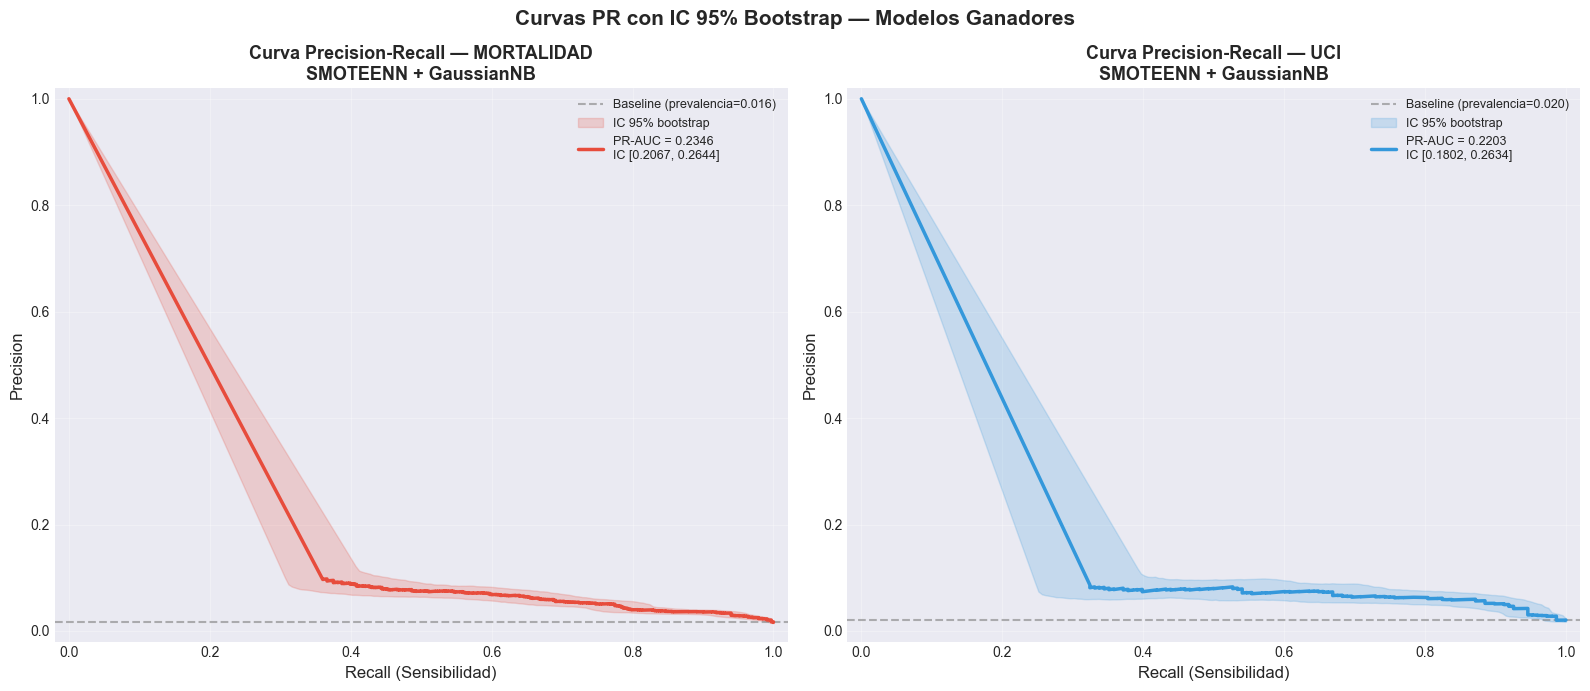

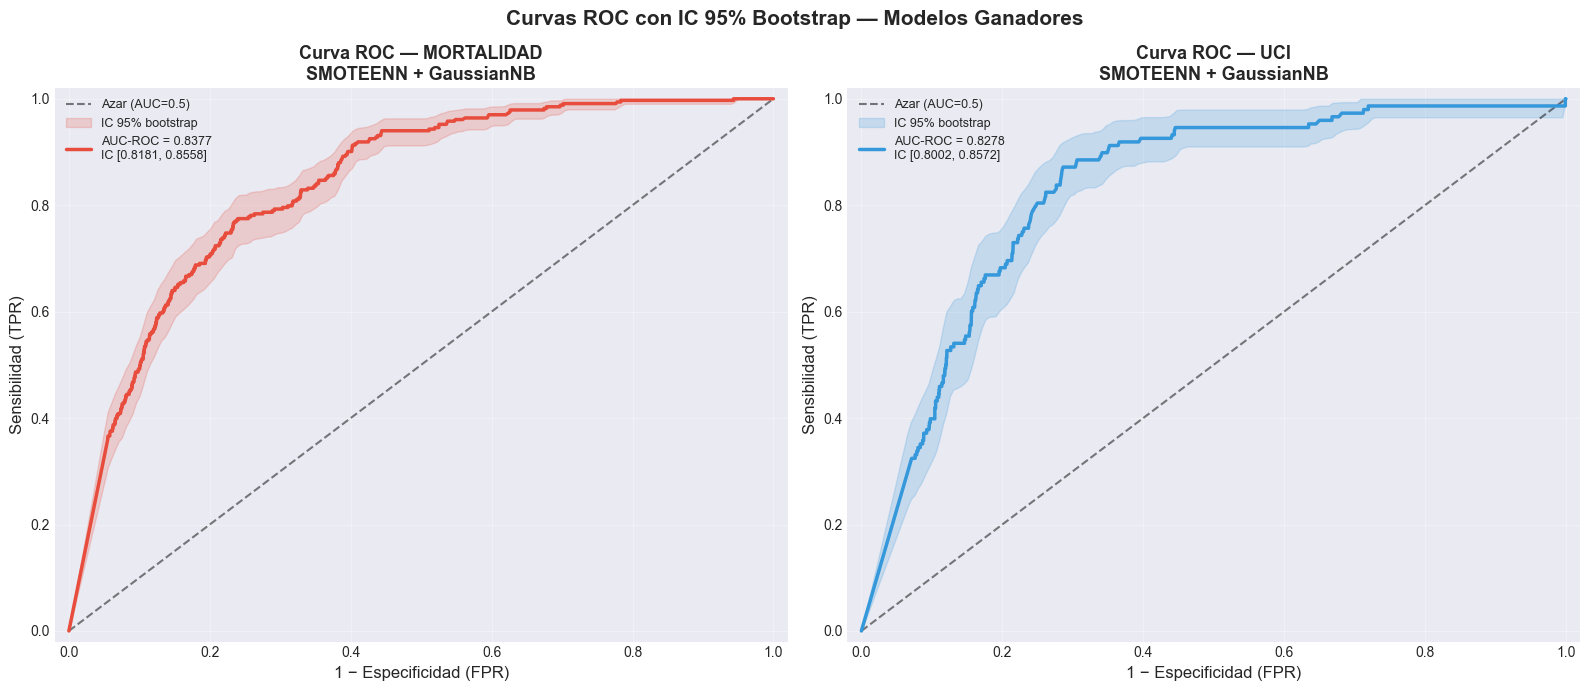

In [17]:
# ============================================================================
# CURVAS PR Y ROC CON BANDA DE CONFIANZA AL 95% (BOOTSTRAP)
# ============================================================================
# Usamos y_test e y_pred_proba almacenados en el checkpoint de GridSearch.
# Referencia: Efron & Tibshirani (1994) — percentile bootstrap.
# ============================================================================
from sklearn.metrics import (precision_recall_curve, roc_curve,
                              roc_auc_score, auc)
from scipy.interpolate import interp1d

SEED    = 42
N_BOOT  = 1000
col_map = {'MORTALIDAD': '#e74c3c', 'UCI': '#3498db'}

# ── PR curves ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, target in zip(axes, ['MORTALIDAD', 'UCI']):
    if target not in ganador_checkpoints:
        ax.text(0.5, 0.5, f'Sin datos: {target}\nEjecuta los ntb_02',
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        continue
    res    = ganador_checkpoints[target]
    y_test = np.array(res['y_test'])
    y_prob = np.array(res['y_pred_proba'])
    g      = ganadores[target]
    color  = col_map[target]

    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    pr_auc_val   = auc(rec, prec)

    rng_b     = np.random.RandomState(SEED)
    rec_grid  = np.linspace(0, 1, 200)
    boot_precs, pr_auc_boots = [], []
    for _ in range(N_BOOT):
        idx = rng_b.choice(len(y_test), size=len(y_test), replace=True)
        yt, yp = y_test[idx], y_prob[idx]
        if len(np.unique(yt)) < 2:
            continue
        p_b, r_b, _ = precision_recall_curve(yt, yp)
        fn = interp1d(r_b[::-1], p_b[::-1], kind='linear',
                      bounds_error=False, fill_value=(p_b[-1], p_b[0]))
        boot_precs.append(fn(rec_grid))
        pr_auc_boots.append(auc(r_b, p_b))
    boot_mat  = np.array(boot_precs)
    ci_lo     = np.percentile(boot_mat, 2.5, axis=0)
    ci_hi     = np.percentile(boot_mat, 97.5, axis=0)
    ci_prauc  = (np.percentile(pr_auc_boots, 2.5), np.percentile(pr_auc_boots, 97.5))

    ax.axhline(y_test.mean(), color='gray', ls='--', alpha=0.6,
               label=f'Baseline (prevalencia={y_test.mean():.3f})')
    ax.fill_between(rec_grid, ci_lo, ci_hi, alpha=0.2, color=color, label='IC 95% bootstrap')
    ax.plot(rec, prec, lw=2.5, color=color,
            label=f'PR-AUC = {pr_auc_val:.4f}\nIC [{ci_prauc[0]:.4f}, {ci_prauc[1]:.4f}]')
    ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.02])
    ax.set_xlabel('Recall (Sensibilidad)', fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.set_title(f'Curva Precision-Recall — {target}\n{g["tecnica"]} + {g["modelo"]}',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('Curvas PR con IC 95% Bootstrap — Modelos Ganadores',
             fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

# ── ROC curves ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, target in zip(axes, ['MORTALIDAD', 'UCI']):
    if target not in ganador_checkpoints:
        continue
    res    = ganador_checkpoints[target]
    y_test = np.array(res['y_test'])
    y_prob = np.array(res['y_pred_proba'])
    g      = ganadores[target]
    color  = col_map[target]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = roc_auc_score(y_test, y_prob)

    fpr_grid = np.linspace(0, 1, 200)
    rng_r    = np.random.RandomState(SEED)
    boot_tprs, boot_aucs = [], []
    for _ in range(N_BOOT):
        idx = rng_r.choice(len(y_test), size=len(y_test), replace=True)
        yt, yp = y_test[idx], y_prob[idx]
        if len(np.unique(yt)) < 2:
            continue
        fp_b, tp_b, _ = roc_curve(yt, yp)
        boot_tprs.append(np.interp(fpr_grid, fp_b, tp_b))
        boot_aucs.append(roc_auc_score(yt, yp))
    ci_tpr = np.percentile(np.array(boot_tprs), [2.5, 97.5], axis=0)
    ci_auc = (np.percentile(boot_aucs, 2.5), np.percentile(boot_aucs, 97.5))

    ax.plot([0,1],[0,1],'k--', alpha=0.5, label='Azar (AUC=0.5)')
    ax.fill_between(fpr_grid, ci_tpr[0], ci_tpr[1], alpha=0.2, color=color, label='IC 95% bootstrap')
    ax.plot(fpr, tpr, lw=2.5, color=color,
            label=f'AUC-ROC = {roc_auc_val:.4f}\nIC [{ci_auc[0]:.4f}, {ci_auc[1]:.4f}]')
    ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.02])
    ax.set_xlabel('1 − Especificidad (FPR)', fontsize=12)
    ax.set_ylabel('Sensibilidad (TPR)', fontsize=12)
    ax.set_title(f'Curva ROC — {target}\n{g["tecnica"]} + {g["modelo"]}',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('Curvas ROC con IC 95% Bootstrap — Modelos Ganadores',
             fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()


### 9.3 — Recalibración probabilística (Isotonic Regression)

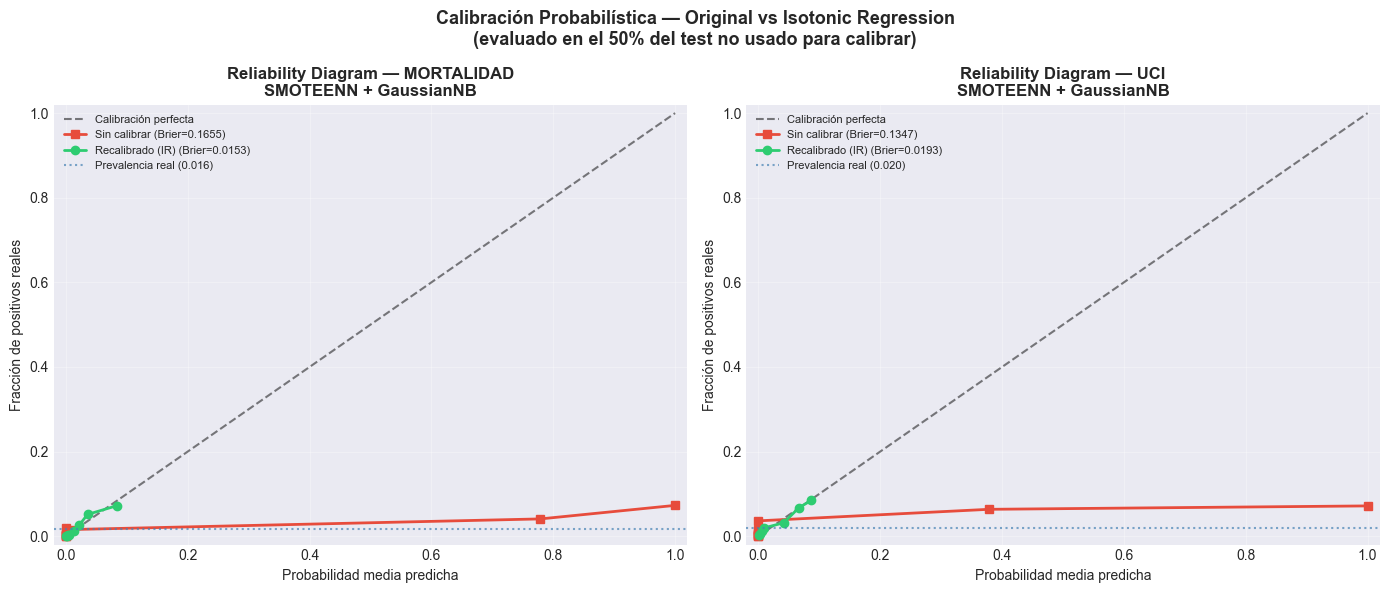

In [18]:
# ============================================================================
# CALIBRACIÓN PROBABILÍSTICA — Reliability diagram antes y después
# ============================================================================
# Los modelos entrenados con oversampling (~30% positivos) predicen probabilidades
# infladas respecto a la prevalencia real (~1-2%). IsotonicRegression las corrige.
# Evaluación honesta: split 50/50 estratificado → calibrar en cal_set, evaluar en eval_set.
# ============================================================================
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
calibrated_info = {}

for ax, target in zip(axes, ['MORTALIDAD', 'UCI']):
    if target not in ganador_checkpoints:
        ax.set_visible(False)
        continue
    res      = ganador_checkpoints[target]
    y_test   = np.array(res['y_test'])
    y_prob   = np.array(res['y_pred_proba'])
    g        = ganadores[target]

    # Split estratificado 50/50 (evita calibrar y evaluar en el mismo conjunto)
    cal_idx, eval_idx = train_test_split(
        np.arange(len(y_test)), test_size=0.5,
        stratify=y_test, random_state=SEED
    )
    y_cal_true  = y_test[cal_idx];   y_prob_cal_in = y_prob[cal_idx]
    y_eval_true = y_test[eval_idx];  y_prob_eval   = y_prob[eval_idx]

    ir = IsotonicRegression(out_of_bounds='clip')
    ir.fit(y_prob_cal_in, y_cal_true)
    y_prob_eval_cal = ir.predict(y_prob_eval)

    calibrated_info[target] = {
        'ir': ir, 'y_eval': y_eval_true,
        'y_orig': y_prob_eval, 'y_cal': y_prob_eval_cal
    }

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Calibración perfecta')
    for y_p, lbl, col, mk in [
        (y_prob_eval,     'Sin calibrar', '#e74c3c', 's-'),
        (y_prob_eval_cal, 'Recalibrado (IR)', '#2ecc71', 'o-')
    ]:
        prob_true, prob_pred = calibration_curve(y_eval_true, y_p, n_bins=10, strategy='quantile')
        bs  = brier_score_loss(y_eval_true, y_p)
        ax.plot(prob_pred, prob_true, mk, lw=2, label=f'{lbl} (Brier={bs:.4f})', color=col)

    prev = y_test.mean()
    ax.axhline(prev, color='steelblue', ls=':', alpha=0.7,
               label=f'Prevalencia real ({prev:.3f})')
    ax.set_title(f'Reliability Diagram — {target}\n{g["tecnica"]} + {g["modelo"]}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Probabilidad media predicha')
    ax.set_ylabel('Fracción de positivos reales')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.02])

plt.suptitle('Calibración Probabilística — Original vs Isotonic Regression\n'
             '(evaluado en el 50% del test no usado para calibrar)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


### 9.4 — Análisis del umbral de decisión y matricez de confusión


  ANÁLISIS DE UMBRALES DE DECISIÓN
  Target         Umbral                     Thr     Prec   Recall      F1     FN      FP
  ----------------------------------------------------------------------------
  MORTALIDAD     Default (0.5)            0.500   0.0600   0.6697  0.1102    110    3493
  MORTALIDAD     F1-max                   0.988   0.0671   0.6186  0.1210    127    2865
  MORTALIDAD     Recall ≥ 90%             0.100   0.0562   0.6907  0.1039    103    3864

  UCI            Default (0.5)            0.500   0.0780   0.5405  0.1363     68     946
  UCI            F1-max                   0.990   0.0826   0.5270  0.1429     70     866
  UCI            Recall ≥ 90%             0.100   0.0758   0.5405  0.1330     68     975



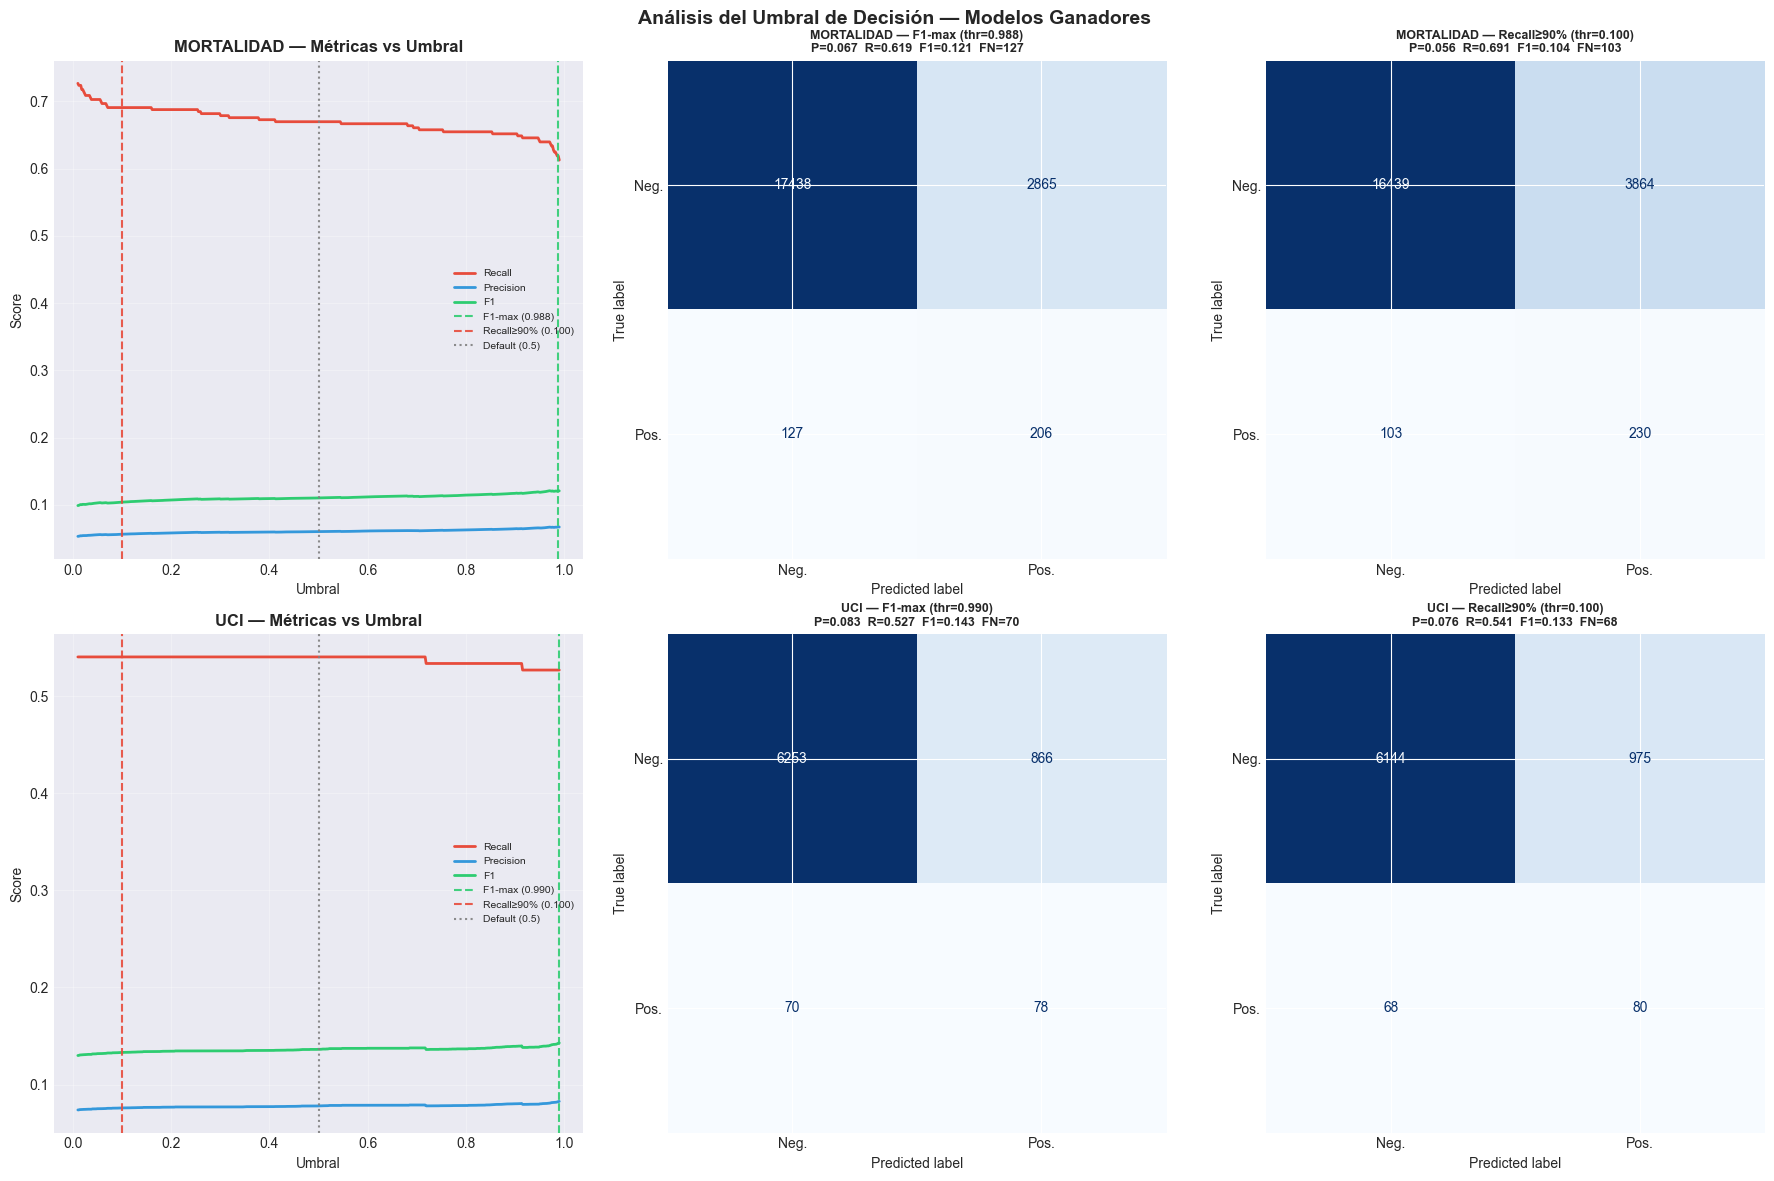

In [19]:
# ============================================================================
# ANÁLISIS DEL UMBRAL DE DECISIÓN
# ============================================================================
# sklearn usa threshold=0.5 por defecto. Con datos muy desbalanceados casi
# ninguna probabilidad supera 0.5, produciendo recall~0.
# Se evalúan tres umbrales:
#   1. Default (0.5)       — referencia
#   2. F1-max              — maximiza F1 (equilibrio precision/recall)
#   3. Recall ≥ 90%        — garantiza detectar al menos el 90% de casos positivos
#                             (umbral clínicamente prioritario: coste del FN alto)
# ============================================================================
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay)

threshold_results = {}
fig_cm, axes_cm  = plt.subplots(2, 3, figsize=(18, 12))

for row_i, target in enumerate(['MORTALIDAD', 'UCI']):
    if target not in ganador_checkpoints:
        continue
    res    = ganador_checkpoints[target]
    y_test = np.array(res['y_test'])
    y_prob = np.array(res['y_pred_proba'])
    g      = ganadores[target]

    thresholds = np.linspace(0.01, 0.99, 500)
    f1s, precs, recs = [], [], []
    for thr in thresholds:
        yp = (y_prob >= thr).astype(int)
        f1s.append(f1_score(y_test, yp, zero_division=0))
        precs.append(precision_score(y_test, yp, zero_division=0))
        recs.append(recall_score(y_test, yp, zero_division=0))
    f1s, precs, recs = np.array(f1s), np.array(precs), np.array(recs)

    thr_f1max   = float(thresholds[np.argmax(f1s)])
    rec90_mask  = recs >= 0.90
    thr_rec90   = float(thresholds[np.where(rec90_mask)[0][0]]) if rec90_mask.any() else 0.10
    thr_default = 0.5
    threshold_results[target] = {
        'thr_f1max': thr_f1max, 'thr_rec90': thr_rec90, 'thr_default': thr_default
    }

    # ── Gráfico: Precision / Recall / F1 vs threshold ──────────────────────
    ax_c = axes_cm[row_i, 0]
    ax_c.plot(thresholds, recs,  lw=2, color='#e74c3c', label='Recall')
    ax_c.plot(thresholds, precs, lw=2, color='#3498db', label='Precision')
    ax_c.plot(thresholds, f1s,   lw=2, color='#2ecc71', label='F1')
    ax_c.axvline(thr_f1max,   color='#2ecc71', ls='--', alpha=0.9, lw=1.5,
                 label=f'F1-max ({thr_f1max:.3f})')
    ax_c.axvline(thr_rec90,   color='#e74c3c', ls='--', alpha=0.9, lw=1.5,
                 label=f'Recall≥90% ({thr_rec90:.3f})')
    ax_c.axvline(thr_default, color='gray',    ls=':',  alpha=0.9,
                 label='Default (0.5)')
    ax_c.set_title(f'{target} — Métricas vs Umbral', fontweight='bold')
    ax_c.set_xlabel('Umbral'); ax_c.set_ylabel('Score')
    ax_c.legend(fontsize=7.5); ax_c.grid(alpha=0.3)

    # ── Matrices de confusión ────────────────────────────────────────────────
    for col_i, (thr, thr_label) in enumerate(
        [(thr_f1max, f'F1-max (thr={thr_f1max:.3f})'),
         (thr_rec90, f'Recall≥90% (thr={thr_rec90:.3f})')], start=1
    ):
        ax_m = axes_cm[row_i, col_i]
        yp   = (y_prob >= thr).astype(int)
        cm   = confusion_matrix(y_test, yp)
        tn_, fp_, fn_, tp_ = cm.ravel()
        ConfusionMatrixDisplay(cm, display_labels=['Neg.', 'Pos.']).plot(
            ax=ax_m, colorbar=False, cmap='Blues')
        p_ = precision_score(y_test, yp, zero_division=0)
        r_ = recall_score(y_test, yp, zero_division=0)
        f_ = f1_score(y_test, yp, zero_division=0)
        ax_m.set_title(
            f'{target} — {thr_label}\n'
            f'P={p_:.3f}  R={r_:.3f}  F1={f_:.3f}  FN={fn_}',
            fontsize=9, fontweight='bold'
        )

# Print text summary
print('\n' + '='*90)
print('  ANÁLISIS DE UMBRALES DE DECISIÓN')
print('='*90)
print(f'  {"Target":<14} {"Umbral":<22} {"Thr":>7} {"Prec":>8} {"Recall":>8} {"F1":>7} {"FN":>6} {"FP":>7}')
print('  ' + '-'*76)
for target in ['MORTALIDAD', 'UCI']:
    if target not in ganador_checkpoints:
        continue
    y_test = np.array(ganador_checkpoints[target]['y_test'])
    y_prob = np.array(ganador_checkpoints[target]['y_pred_proba'])
    tr     = threshold_results[target]
    for thr_val, thr_name in [
        (tr['thr_default'], 'Default (0.5)'),
        (tr['thr_f1max'],   'F1-max'),
        (tr['thr_rec90'],   'Recall ≥ 90%')
    ]:
        yp  = (y_prob >= thr_val).astype(int)
        cm  = confusion_matrix(y_test, yp)
        fn_ = cm[1, 0]; fp_ = cm[0, 1]
        print(f'  {target:<14} {thr_name:<22} {thr_val:>7.3f} '
              f'{precision_score(y_test, yp, zero_division=0):>8.4f} '
              f'{recall_score(y_test, yp, zero_division=0):>8.4f} '
              f'{f1_score(y_test, yp, zero_division=0):>7.4f} {fn_:>6} {fp_:>7}')
    print()

plt.suptitle('Análisis del Umbral de Decisión — Modelos Ganadores',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


### 9.5 — Importancia de variables (SHAP)

/Users/ikerarias/miniconda3/envs/tfg_ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



SHAP — MORTALIDAD: SMOTEENN + GaussianNB


100%|██████████| 300/300 [00:00<00:00, 315.01it/s]
/var/folders/yf/xytvt_615f9cchf9bxlczkdc0000gn/T/ipykernel_15880/2071205979.py:47: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_shap, show=False, max_display=15, plot_size=None)


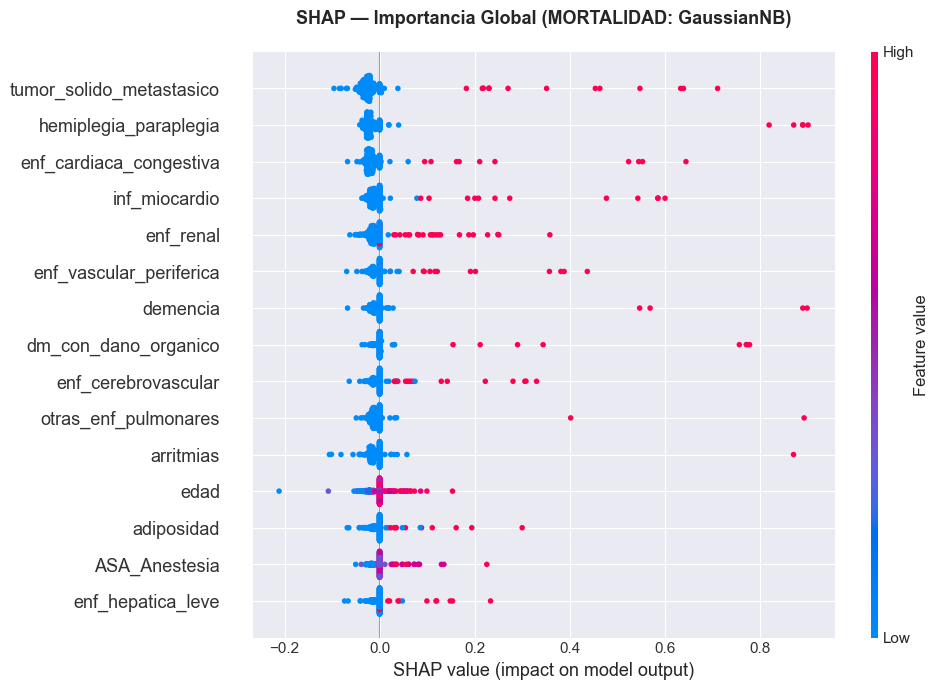

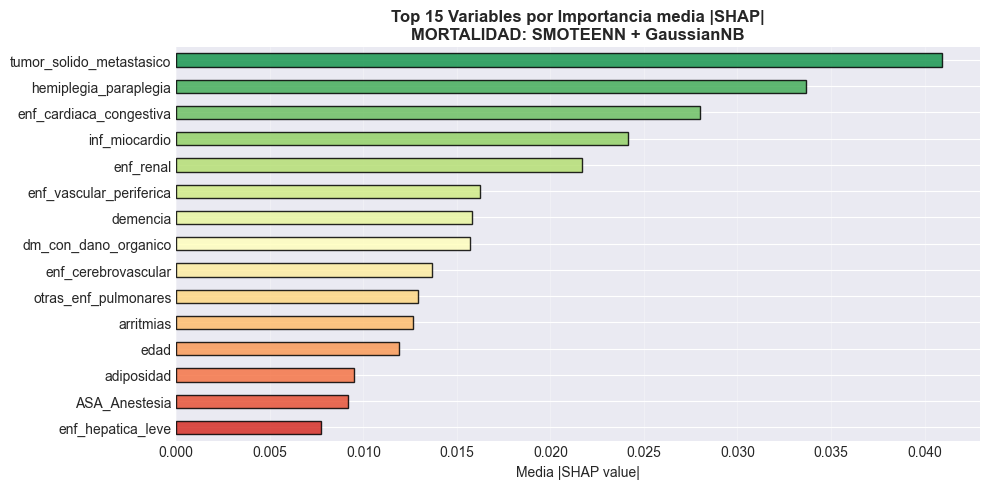

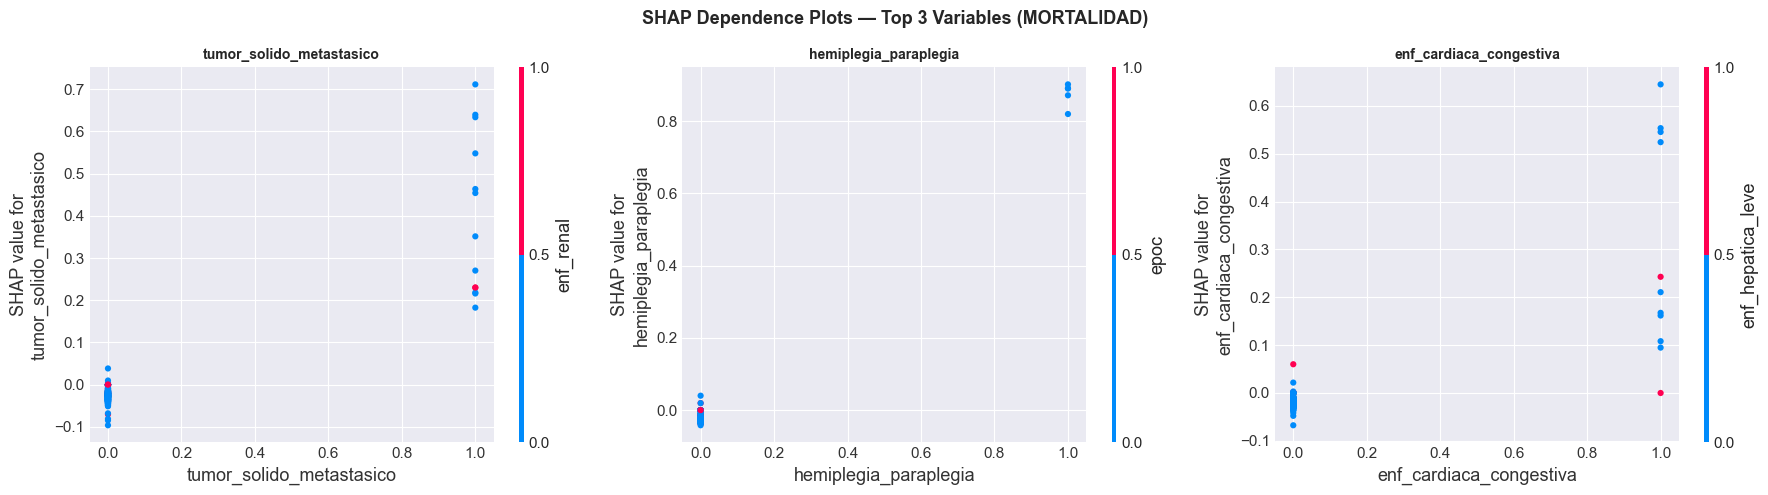

  ✓ SHAP completado para MORTALIDAD

SHAP — UCI: SMOTEENN + GaussianNB


100%|██████████| 300/300 [00:01<00:00, 297.88it/s]
/var/folders/yf/xytvt_615f9cchf9bxlczkdc0000gn/T/ipykernel_15880/2071205979.py:47: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_shap, show=False, max_display=15, plot_size=None)


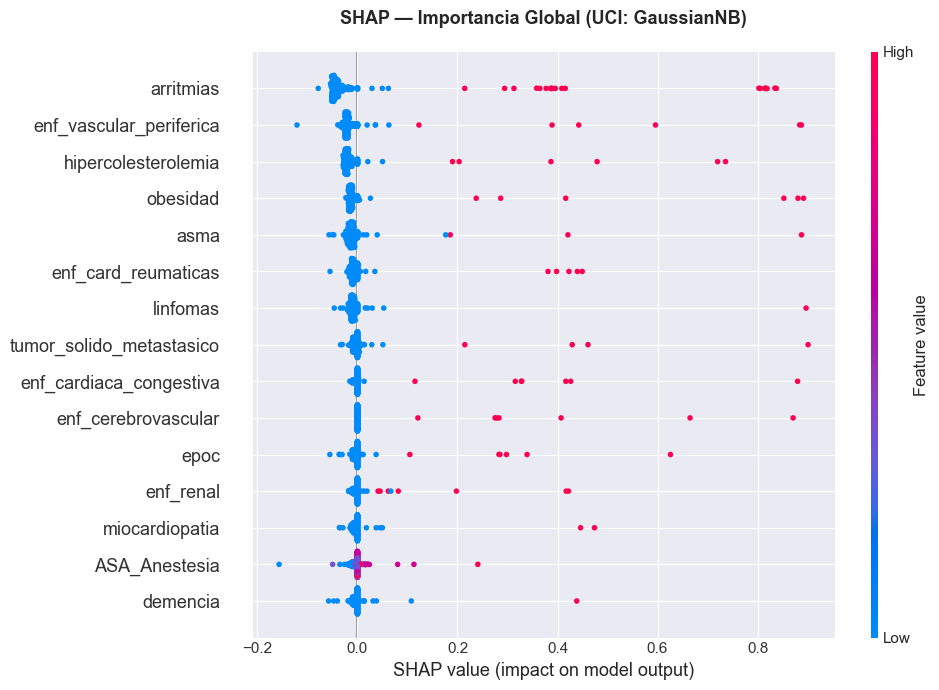

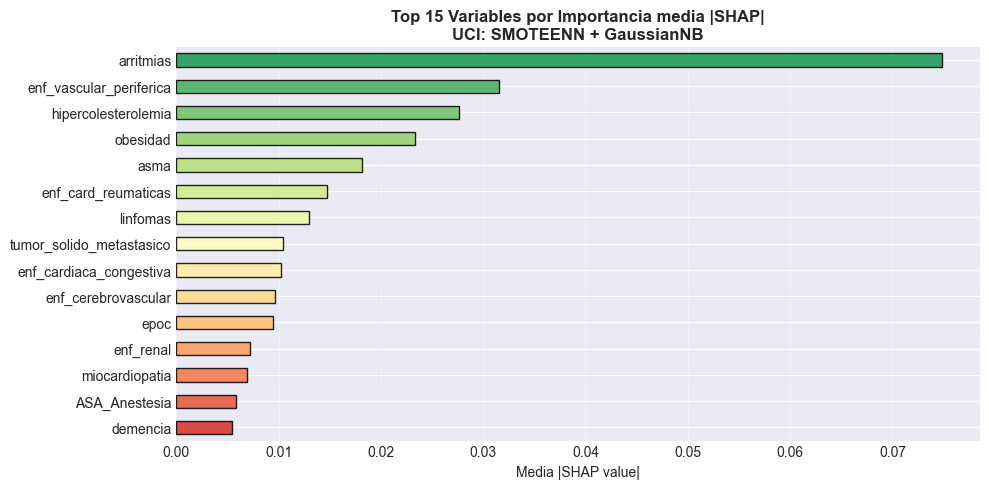

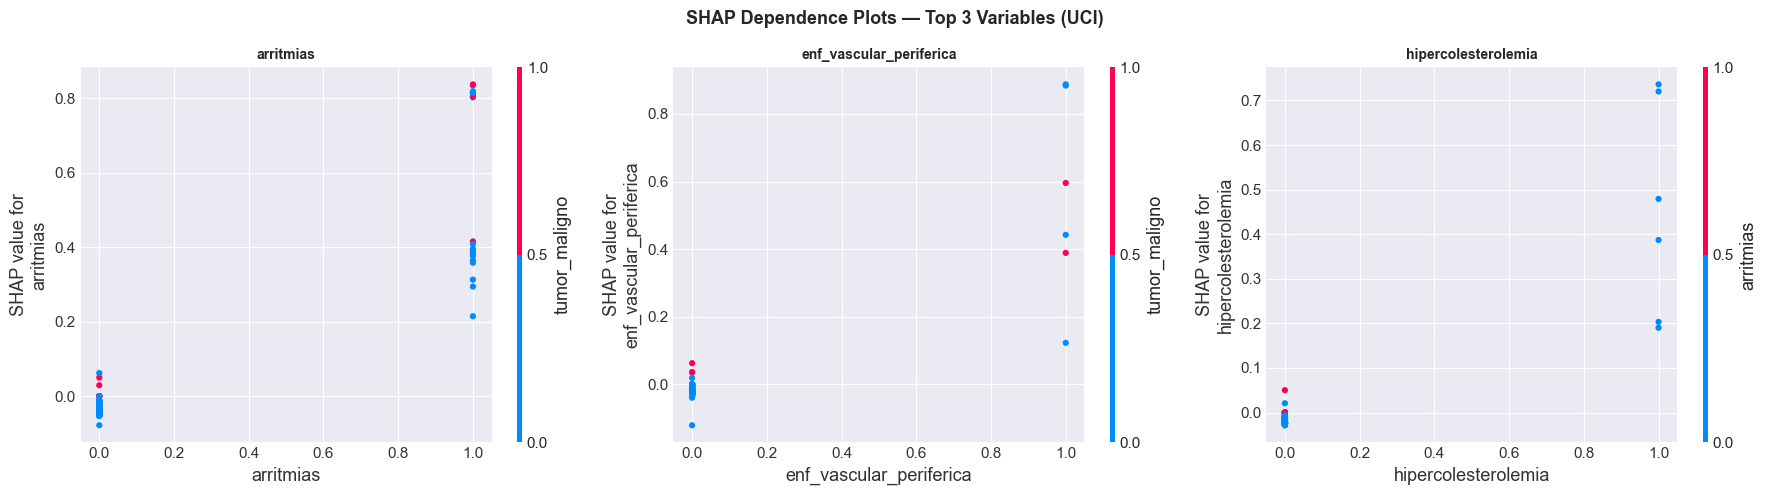

  ✓ SHAP completado para UCI


In [20]:
# ============================================================================
# SHAP — Importancia global de variables para el modelo ganador
# ============================================================================
# TreeExplainer para árboles (XGB, RF, GradientBoosting, ExtraTrees, LightGBM).
# KernelExplainer + submuestra (100 fondo, 100 eval) para LR y GaussianNB.
# X_test_scaled (features preprocesadas) se carga directamente del checkpoint.
# ============================================================================
import shap

TREE_MODELS      = {'XGBoost', 'RandomForest', 'GradientBoosting', 'ExtraTrees', 'LightGBM'}
SHAP_MAX_SAMPLES = 300

for target in ['MORTALIDAD', 'UCI']:
    if target not in ganador_checkpoints:
        continue
    res         = ganador_checkpoints[target]
    g           = ganadores[target]
    modelo_base = res['best_model']
    X_scaled    = res['X_test_scaled']
    nombre      = g['modelo']

    print(f'\n{"="*60}')
    print(f'SHAP — {target}: {g["tecnica"]} + {nombre}')
    print(f'{"="*60}')

    # Subsamplear si hay más de SHAP_MAX_SAMPLES filas
    if len(X_scaled) > SHAP_MAX_SAMPLES:
        idx_s = np.random.RandomState(SEED).choice(
            len(X_scaled), SHAP_MAX_SAMPLES, replace=False)
        X_shap = X_scaled.iloc[idx_s].reset_index(drop=True)
    else:
        X_shap = X_scaled.reset_index(drop=True)
    X_shap.columns = [str(c) for c in X_shap.columns]

    if nombre in TREE_MODELS:
        explainer   = shap.TreeExplainer(modelo_base)
        shap_values = explainer.shap_values(X_shap)
        sv = shap_values[1] if isinstance(shap_values, list) else shap_values
    else:
        background  = shap.sample(X_shap, min(100, len(X_shap)), random_state=SEED)
        explainer   = shap.KernelExplainer(
            lambda x: modelo_base.predict_proba(x)[:, 1], background)
        sv = explainer.shap_values(X_shap, nsamples=100)

    # ── Beeswarm summary plot ────────────────────────────────────
    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv, X_shap, show=False, max_display=15, plot_size=None)
    plt.title(f'SHAP — Importancia Global ({target}: {nombre})',
              fontsize=13, fontweight='bold', pad=20)
    plt.tight_layout(); plt.show()

    # ── Bar plot: media |SHAP| ───────────────────────────────────
    mean_abs = pd.Series(np.abs(sv).mean(axis=0),
                         index=X_shap.columns).sort_values(ascending=False).head(15)
    fig, ax  = plt.subplots(figsize=(10, 5))
    cmap_arr = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(mean_abs)))
    mean_abs.sort_values().plot(kind='barh', ax=ax,
                                color=cmap_arr[::-1], edgecolor='black', alpha=0.85)
    ax.set_title(
        f'Top 15 Variables por Importancia media |SHAP|\n'
        f'{target}: {g["tecnica"]} + {nombre}',
        fontsize=12, fontweight='bold')
    ax.set_xlabel('Media |SHAP value|'); ax.grid(axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()

    # ── Dependence plots: top 3 variables ───────────────────────
    top3 = mean_abs.index[:3].tolist()
    fig, axes_dep = plt.subplots(1, 3, figsize=(18, 5))
    for ax_d, feat in zip(axes_dep, top3):
        shap.dependence_plot(feat, sv, X_shap, ax=ax_d, show=False,
                             interaction_index='auto', dot_size=20)
        ax_d.set_title(f'{feat}', fontsize=10, fontweight='bold')
    plt.suptitle(f'SHAP Dependence Plots — Top 3 Variables ({target})',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    print(f'  ✓ SHAP completado para {target}')


### 9.6 — Tabla clínica de resultados para la defensa del TFG

In [21]:
# ============================================================================
# TABLA CLÍNICA FINAL — Para la presentación y defensa del TFG
# Resume: identificación del modelo, métricas, umbral óptimo, K-Fold robustez
# ============================================================================
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

print('\n' + '='*110)
print('  TABLA CLÍNICA FINAL — MODELO GANADOR POR TARGET')
print('='*110)

for target in ['MORTALIDAD', 'UCI']:
    if target not in ganador_checkpoints:
        print(f'\n  {target}: sin checkpoint disponible.')
        continue
    g      = ganadores[target]
    res    = ganador_checkpoints[target]
    y_test = np.array(res['y_test'])
    y_prob = np.array(res['y_pred_proba'])
    n_test = len(y_test)
    n_pos  = int(y_test.sum())
    n_neg  = n_test - n_pos
    prev   = n_pos / n_test * 100

    # Umbral F1-max
    thrs_c = np.linspace(0.01, 0.99, 500)
    f1s_c  = [f1_score(y_test, (y_prob >= t).astype(int), zero_division=0) for t in thrs_c]
    thr_opt = float(thrs_c[np.argmax(f1s_c)])
    yp_opt  = (y_prob >= thr_opt).astype(int)
    cm_opt  = confusion_matrix(y_test, yp_opt)
    tn_o, fp_o, fn_o, tp_o = cm_opt.ravel()

    # K-Fold robustez
    kf_row  = df_all[(df_all['Target']   == target) &
                     (df_all['Fase']     == 'K-Fold (5)') &
                     (df_all['Modelo']   == g['modelo']) &
                     (df_all['Tecnica']  == g['tecnica'])]
    kf_prauc = float(kf_row.iloc[0]['PR-AUC']) if not kf_row.empty else float('nan')
    kf_info  = kf_row.iloc[0]['Info']          if not kf_row.empty else 'N/A'

    vpp = tp_o / (tp_o + fp_o) if (tp_o + fp_o) > 0 else float('nan')
    vpn = tn_o / (tn_o + fn_o) if (tn_o + fn_o) > 0 else float('nan')

    print(f'''
  ══════════════════════════════════════════════════════════════════════
  TARGET: {target}  (prevalencia en test: {prev:.2f}% — {n_pos} positivos / {n_test:,} total)
  ══════════════════════════════════════════════════════════════════════
  Técnica de balanceo  : {g['tecnica']}
  Algoritmo ML         : {g['modelo']}
  ──────────────────────────────────────────────────────────────────────
  RENDIMIENTO — GridSearch (test set held-out, 20% del total)
    PR-AUC  (métrica principal) : {g['pr_auc']:.4f}
    AUC-ROC                     : {g['auc_roc']:.4f}
    Precision                   : {g['precision']:.4f}
    Recall                      : {g['recall']:.4f}
    F1-Score                    : {g['f1']:.4f}
  ──────────────────────────────────────────────────────────────────────
  ROBUSTEZ — K-Fold (5 folds, mismos grupos, sin shuffle)
    PR-AUC media K-Fold         : {kf_prauc:.4f}  ({kf_info})
  ──────────────────────────────────────────────────────────────────────
  UMBRAL ÓPTIMO (F1-max sobre test set)
    Umbral seleccionado         : {thr_opt:.4f}  (vs default 0.5)
    Precision @ umbral          : {precision_score(y_test, yp_opt, zero_division=0):.4f}
    Recall    @ umbral          : {recall_score(y_test, yp_opt, zero_division=0):.4f}
    F1        @ umbral          : {f1_score(y_test, yp_opt, zero_division=0):.4f}
  ──────────────────────────────────────────────────────────────────────
  MATRIZ DE CONFUSIÓN @ umbral {thr_opt:.4f}
    TP  (eventos detectados)    : {tp_o:>6}   → correctamente identificados
    FP  (falsas alarmas)        : {fp_o:>6}   → pacientes sanos alertados innecesariamente
    TN  (negativos correctos)   : {tn_o:>6}
    FN  (casos perdidos ⚠)     : {fn_o:>6}   → coste clínico más alto
    VPP (Valor Pred. Positivo)  : {vpp:.4f}   → de cada alarma, el {vpp*100:.1f}% es real
    VPN (Valor Pred. Negativo)  : {vpn:.4f}
  ══════════════════════════════════════════════════════════════════════''')

notas = (
    '\n  NOTAS METODOLÓGICAS:\n'
    '  ─────────────────────────────────────────────────────────────────────────────\n'
    '  · PR-AUC es la métrica de selección principal: robusta a la prevalencia baja.\n'
    '  · AUC-ROC complementa la evaluación de discriminación global.\n'
    '  · K-Fold comparte exactamente los mismos 5 folds en todos los notebooks\n'
    '    (StratifiedGroupKFold, sin shuffle) → comparación Friedman/Wilcoxon válida.\n'
    '  · FN tiene mayor coste clínico: un evento no detectado (muerte/UCI) es más\n'
    '    grave que una falsa alarma → umbral Recall≥90% recomendado en clínica.\n'
    '  ─────────────────────────────────────────────────────────────────────────────\n'
)
print(notas)



  TABLA CLÍNICA FINAL — MODELO GANADOR POR TARGET

  ══════════════════════════════════════════════════════════════════════
  TARGET: MORTALIDAD  (prevalencia en test: 1.61% — 333 positivos / 20,636 total)
  ══════════════════════════════════════════════════════════════════════
  Técnica de balanceo  : SMOTEENN
  Algoritmo ML         : GaussianNB
  ──────────────────────────────────────────────────────────────────────
  RENDIMIENTO — GridSearch (test set held-out, 20% del total)
    PR-AUC  (métrica principal) : 0.2346
    AUC-ROC                     : 0.8377
    Precision                   : 0.0600
    Recall                      : 0.6697
    F1-Score                    : 0.1102
  ──────────────────────────────────────────────────────────────────────
  ROBUSTEZ — K-Fold (5 folds, mismos grupos, sin shuffle)
    PR-AUC media K-Fold         : 0.2187  (±0.0128 (PR-AUC std))
  ──────────────────────────────────────────────────────────────────────
  UMBRAL ÓPTIMO (F1-max sobre test set)
 